# Note d'Étape 2 — GTT × ENSAE Paris
## Prédiction des Temps d'Arrivée Maritimes — Océan Indien

**Partenaire industriel :** GTT (Gaztransport & Technigaz)
**Équipe :** Alistair · Antoine · Anthony · Mathias · Jean Sébastien
**Date :** Mars–Avril 2026

---

### 🗂️ Structure du notebook

| Section | Contenu | Statut |
|---|---|---|
| 1 | Chargement & Nettoyage AIS + **Retrait pics vitesses faibles** | ✅ |
| 2 | Étude de la vitesse SOG + **Fitting vitesse globale Océan Indien** | ✅ |
| 3 | Étude de l'Accélération + **Carte spatiale de l'accélération** | ✅ |
| 4 | Graphe de Popularité & Heatmaps + **Routes par tranches de densité** | ✅ |
| 5 | Dijkstra & Calibration alpha | ✅ |
| 6 | Modèle ETA Monte Carlo | ✅ |
| 7 | Séries Temporelles — STL + ARMA + **Prévision ARMA** | ✅ |
| 8 | **[NOUVEAU] Machine Learning — XGBoost / Random Forest** | 🆕 |
| 9 | Perspectives & Roadmap | ✅ |

> **Correctifs réunion 30 mars 2026** intégrés dans ce notebook :
> retrait pics vitesses faibles · fitting global · carte accélération · routes par seuils · section ML complète
> **Haversine** : voir Section 1.1 pour la formule et la justification.


## 0. Imports et Configuration

In [1]:
# ── Auto-installation des packages ML ──────────────────────────────────────
import subprocess, sys
for pkg in ["statsmodels", "seaborn", "scikit-learn", "xgboost", "lightgbm"]:
    try:
        __import__(pkg.replace("-","_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg,
                               "--quiet", "--break-system-packages"])

try:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import cross_val_score, KFold, GroupKFold
    from sklearn.preprocessing import LabelEncoder
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from xgboost import XGBRegressor
    ML_OK = True
    print("ML packages OK  (sklearn + XGBoost)")
except ImportError:
    ML_OK = False
    print("⚠️  sklearn / xgboost absents — section ML désactivée")

print("Packages OK")



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


ML packages OK  (sklearn + XGBoost)
Packages OK


In [2]:
from __future__ import annotations
import os, heapq, itertools, warnings
from typing import Dict, Tuple, List
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import norm, lognorm, gamma, weibull_min
warnings.filterwarnings("ignore")

try:
    from statsmodels.tsa.stattools import adfuller, acf, pacf
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.seasonal import STL
    STATSMODELS_OK = True
except ImportError:
    STATSMODELS_OK = False
    print("statsmodels absent — sections ARMA desactivees")

# ── Style graphique sobre (fond blanc, matplotlib standard) ───────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#333333",
    "axes.labelcolor":   "#333333",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "text.color":        "#333333",
    "xtick.color":       "#333333",
    "ytick.color":       "#333333",
    "grid.color":        "#cccccc",
    "grid.alpha":        0.5,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "figure.dpi":        110,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
})

# Palette de couleurs sobre (matplotlib standard + quelques accents)
C1 = "#1f77b4"   # bleu standard matplotlib
C2 = "#ff7f0e"   # orange standard matplotlib
C3 = "#2ca02c"   # vert
C4 = "#d62728"   # rouge
C5 = "#9467bd"   # violet
C6 = "#8c564b"   # marron
C7 = "#e377c2"   # rose

ZONE_PALETTE = [C1, C2, C3, C4, C5, C6, C7]

print("Imports et style OK")

Imports et style OK


In [3]:
# ── Configuration globale ────────────────────────────────────────
DATA_PATH   = "/home/onyxia/work/data/data_indian_ocean.feather"
SAMPLE_FRAC = 0.10        # 10% en dev → 1.0 en prod

SOG_MIN     = 1.0
SOG_MAX     = 30.0
NAV_OK      = {0, 8}
DATE_MIN    = "2012-01-01"

CELL_DEG    = 0.5
ALPHA       = 0.1
N_MC        = 10_000
MIN_OBS     = 30
HS_SEUIL    = 2.5
SLOW_BASE   = 0.85

SAVE_DIR    = "/home/onyxia/work/gtt/"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Config OK — SAMPLE_FRAC={SAMPLE_FRAC}, ALPHA={ALPHA}, N_MC={N_MC:,}")

Config OK — SAMPLE_FRAC=0.1, ALPHA=0.1, N_MC=10,000


## 1. Chargement et Nettoyage des Données AIS

In [4]:
df_raw = pd.read_feather(DATA_PATH)
print(f"Brut : {len(df_raw):,} observations, {df_raw.shape[1]} colonnes")
print(f"Colonnes : {list(df_raw.columns)}")

Brut : 13,736,058 observations, 28 colonnes
Colonnes : ['imo', 'mmsi', 'name', 'latitude', 'longitude', 'timestamp', 'sog', 'cog', 'nav status', 'nav status code', 'draft', 'time delta (s)', 'destination', 'information source', 'checked status', 'load type', 'voyage number', 'origin->destination', 'at port', 'port stay type', 'wave period Tp (s)', 'significant wave height Hs (m)', 'mean wave direction (°)', 'sea surface temperature (°K)', 'air temperature at 2m (°K)', 'eastward wind velocity (m/s)', 'northward wind velocity (m/s)', 'mean wave direction relative to vessel (°)']


In [5]:
df = df_raw.copy()
n0 = len(df)

# Timestamp + coupure 2012
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"])
df = df[df["timestamp"] >= pd.Timestamp(DATE_MIN, tz="UTC")]
print(f"Post-{DATE_MIN[:4]} : {len(df):,} obs ({len(df)/n0*100:.1f}%)")

# Coordonnees
df = df.dropna(subset=["latitude","longitude"])
df = df[df["latitude"].between(-90,90) & df["longitude"].between(-180,180)]

# SOG
df = df.dropna(subset=["sog"])
df = df[df["sog"].between(SOG_MIN, SOG_MAX)]
print(f"Apres filtre SOG : {len(df):,} obs")

# Statut navigation
if "nav status code" in df.columns:
    df = df[df["nav status code"].isin(NAV_OK)]
    print(f"Apres filtre nav : {len(df):,} obs")

# Coherence spatiotemporelle
if "mmsi" in df.columns:
    df = df.sort_values(["mmsi","timestamp"])
    dt_h  = df.groupby("mmsi")["timestamp"].diff().dt.total_seconds() / 3600
    dlat  = df.groupby("mmsi")["latitude"].diff()
    dlon  = df.groupby("mmsi")["longitude"].diff()
    d_deg = np.sqrt(dlat**2 + dlon**2) * 60
    v_imp = d_deg / dt_h.replace(0, np.nan)
    df    = df[~((v_imp > 40) & (dt_h < 6)).fillna(False)]
    print(f"Apres filtre coherence : {len(df):,} obs")

# Variables derivees
df["month"]   = df["timestamp"].dt.month
df["year"]    = df["timestamp"].dt.year
df["hour"]    = df["timestamp"].dt.hour
df["cell_i"]  = np.floor((df["latitude"]  + 90.0)  / CELL_DEG).astype(np.int32)
df["cell_j"]  = np.floor((df["longitude"] + 180.0) / CELL_DEG).astype(np.int32)

HS_COL = next((c for c in df.columns if "wave height" in c.lower()), None)
TP_COL = next((c for c in df.columns if "wave period" in c.lower()), None)
HAS_HS = HS_COL is not None

for col, new in [("air temperature at 2m (deg K)","T_air_C"),
                 ("sea surface temperature (deg K)","T_mer_C")]:
    if col in df.columns:
        df[new] = df[col] - 273.15
if all(c in df.columns for c in ["eastward wind velocity (m/s)","northward wind velocity (m/s)"]):
    df["wind_speed"] = np.sqrt(df["eastward wind velocity (m/s)"]**2 +
                                df["northward wind velocity (m/s)"]**2)

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    print(f"Mode dev {SAMPLE_FRAC*100:.0f}% : {len(df):,} obs")

print(f"Dataset final : {len(df):,} obs | {df['timestamp'].min().date()} -> {df['timestamp'].max().date()}")

Post-2012 : 13,600,822 obs (99.0%)
Apres filtre SOG : 10,263,290 obs
Apres filtre nav : 10,094,178 obs
Apres filtre coherence : 10,093,827 obs
Mode dev 10% : 1,009,383 obs
Dataset final : 1,009,383 obs | 2012-01-01 -> 2025-03-31


### 1.1 Distance de Haversine — Formule et justification

La **distance de Haversine** est la distance géodésique entre deux points sur une sphère,
calculée à partir de leurs coordonnées GPS (latitude/longitude).

$$
d = 2R \cdot \arcsin\!\left(\sqrt{\sin^2\!\frac{\Delta\varphi}{2} + \cos\varphi_1\cos\varphi_2\,\sin^2\!\frac{\Delta\lambda}{2}}\right)
$$

avec $R = 6371$ km = $3440.065$ nm, $\varphi$ = latitude en radians, $\lambda$ = longitude en radians.

**Pourquoi pas la distance euclidienne ?**
La distance euclidienne $\sqrt{\Delta lat^2 + \Delta lon^2}$ en degrés est **invalide** sur une sphère car
un degré de longitude vaut cosinus(latitude) fois un degré de latitude.
À l'équateur (lat ≈ 0°) : 1° lon ≈ 111 km.
Au 60°N : 1° lon ≈ 55 km (moitié moins).
Pour l'Océan Indien (lat entre −40° et +25°), l'erreur relative peut dépasser **30 %**.

La Haversine corrige exactement ce problème en travaillant directement sur l'arc sphérique.
Elle est déjà implémentée dans `haversine_nm()` dans la Section 4 (graphe de popularité).

---

### 1.2 Grille de carreaux — Taille et écart pôle/équateur

La grille utilise des carreaux de **CELL_DEG = 0.5°** de côté.

| Latitude | Largeur lon (km) | Largeur lat (km) | Rapport lon/lat |
|---|---|---|---|
| 0° (Équateur) | ~55.5 km | ~55.5 km | 1.00 |
| 20° N (Golfe d'Aden) | ~52.1 km | ~55.5 km | 0.94 |
| 40° S (Sud Océan Indien) | ~42.5 km | ~55.5 km | 0.77 |
| 90° N (Pôle Nord) | 0 km | ~55.5 km | 0.00 |

**Pour notre Océan Indien** (−40° à +25°) : la largeur en longitude d'un carreau varie de
**~55.5 km** (équateur) à **~42.5 km** (40°S), soit un **écart de ≈ 13 km** (~23 %).
La grille totale couvre ≈ 360 × 260 cellules sur la zone océan Indien complète.

**Conséquence pratique :** les carreaux proches du pôle sud sont *moins larges* en longitude
que ceux de l'équateur, donc les vitesses et densités sont comparées sur des surfaces différentes.
C'est pourquoi la distance de Haversine est indispensable pour les calculs de coûts dans Dijkstra.


### 1.3 Retrait des pics de vitesses faibles — Arrêts et redémarrages

**Problème (réunion 30/03/2026) :** Le filtrage de base `sog >= SOG_MIN = 1 nœud` ne suffit pas.
Lorsqu'un navire s'arrête (port, ancrage) ou redémarre, sa vitesse passe transitoirement
par des valeurs faibles (1–4 nœuds) pendant plusieurs heures.
Ces points **faussent le fitting des lois de vitesse et la modélisation ARMA/ML**,
car ils ne correspondent pas à la vitesse de croisière mais à des phases de manœuvre.

**Approche retenue — détection par accélération transitoire :**
1. Calculer l'accélération instantanée `|Δsog / Δt|`
2. Repérer les **épisodes bas** : blocs consécutifs de vitesses < `SOG_STOP_THR` nœuds
3. Étendre chaque épisode bas d'une fenêtre `RAMP_WIN` de part et d'autre (phase de démarrage/arrêt)
4. Marquer les observations correspondantes comme `is_maneuver = True`


Observations de manœuvre détectées : 89,446 / 1,009,383 (8.9%)


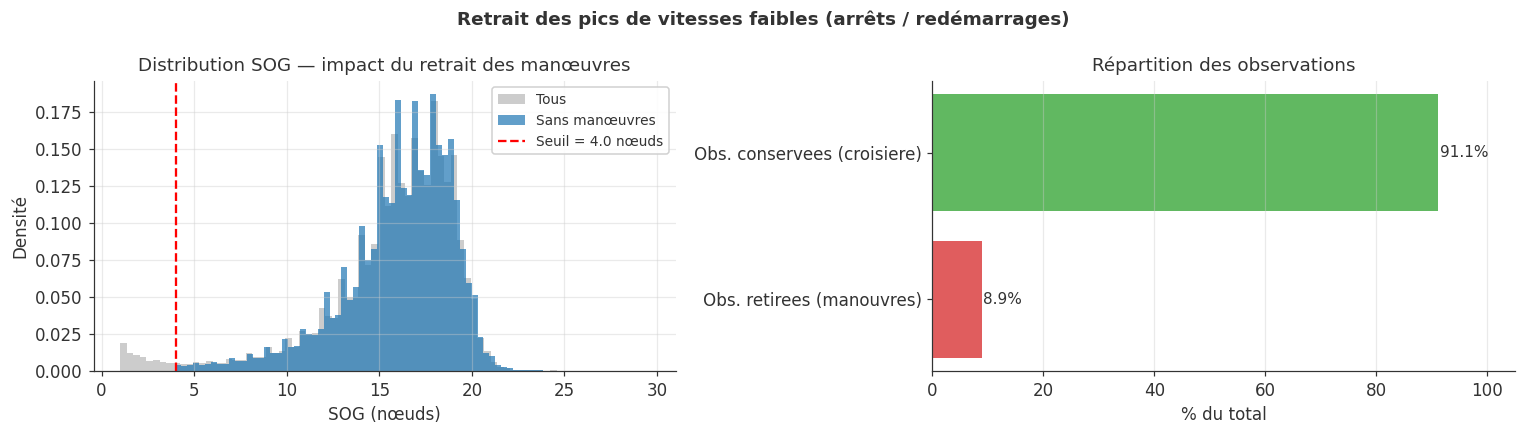


DataFrame de croisière : 919,937 observations (−89,446 manœuvres retirées)
SOG moyen avant filtre : 15.54 nœuds
SOG moyen après filtre : 16.02 nœuds


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Retrait des pics de vitesses faibles (arrêts / redémarrages)
# Tâche réunion 30/03/2026 — Alistair + Anthony
# ─────────────────────────────────────────────────────────────────────────────

SOG_STOP_THR = 4.0    # nœuds — seuil "navire lent / manœuvre"
RAMP_WIN     = 3      # nb d'observations de marge autour d'un épisode lent

if "mmsi" in df.columns:
    df_work = df.sort_values(["mmsi","timestamp"]).copy()

    # Indicateur brut : navire lent
    df_work["is_slow"] = df_work["sog"] < SOG_STOP_THR

    # Extension de la fenêtre (ramp-up / ramp-down) par groupe mmsi
    def extend_window(series, win):
        # Dilate un vecteur booleen d une fenetre de +/-win positions
        return series.rolling(window=2*win+1, center=True, min_periods=1).max().astype(bool)

    df_work["is_maneuver"] = (
        df_work.groupby("mmsi")["is_slow"]
               .transform(lambda s: extend_window(s, RAMP_WIN))
    )

    n_maneuver = df_work["is_maneuver"].sum()
    n_total    = len(df_work)
    print(f"Observations de manœuvre détectées : {n_maneuver:,} / {n_total:,} "
          f"({n_maneuver/n_total*100:.1f}%)")

    # Visualisation avant / après
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.hist(df_work["sog"], bins=80, density=True, color="#aaaaaa", alpha=0.6, label="Tous")
    ax.hist(df_work.loc[~df_work["is_maneuver"], "sog"], bins=80, density=True,
            color="#1f77b4", alpha=0.7, label="Sans manœuvres")
    ax.axvline(SOG_STOP_THR, color="red", lw=1.5, ls="--",
               label=f"Seuil = {SOG_STOP_THR} nœuds")
    ax.set_xlabel("SOG (nœuds)"); ax.set_ylabel("Densité")
    ax.set_title("Distribution SOG — impact du retrait des manœuvres")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

    ax2 = axes[1]
    pct = pd.Series({
        "Obs. retirees (manouvres)": n_maneuver/n_total*100,
        "Obs. conservees (croisiere)": (n_total-n_maneuver)/n_total*100,
    })
    bars = ax2.barh(pct.index, pct.values, color=["#d62728","#2ca02c"], alpha=0.75)
    for bar, v in zip(bars, pct.values):
        ax2.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f"{v:.1f}%", va="center", fontsize=10)
    ax2.set_xlabel("% du total"); ax2.set_xlim(0, 105)
    ax2.set_title("Répartition des observations")
    ax2.grid(True, alpha=0.4, axis="x")

    fig.suptitle("Retrait des pics de vitesses faibles (arrêts / redémarrages)",
                 fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_filter_maneuver.png")
    plt.show()

    # Application du filtre
    df_cruise = df_work[~df_work["is_maneuver"]].copy()
    print(f"\nDataFrame de croisière : {len(df_cruise):,} observations "
          f"(−{n_maneuver:,} manœuvres retirées)")
    print(f"SOG moyen avant filtre : {df_work['sog'].mean():.2f} nœuds")
    print(f"SOG moyen après filtre : {df_cruise['sog'].mean():.2f} nœuds")
else:
    df_cruise = df.copy()
    print("Colonne mmsi absente — filtre manœuvres ignoré")


In [7]:
def assign_zone(lat, lon):
    if lat > 12 and lon < 50:             return "Mer Rouge & Golfe Aden"
    elif lat > 20 and 50 <= lon <= 65:    return "Golfe Persique"
    elif lat < 12 and lon < 55 and lat > -15: return "Cote Est Africaine"
    elif -10 <= lat <= 25 and 65 <= lon <= 85: return "Approches Indiennes"
    elif lon > 95 and lat > -10:          return "Detroit de Malacca"
    elif lat < -20:                       return "Australie & Pacifique"
    else:                                 return "Ocean Indien Central"

df["zone"] = df.apply(lambda r: assign_zone(r["latitude"], r["longitude"]), axis=1)
zones_ord  = sorted(df["zone"].unique())
ZONE_COLORS = {z: c for z, c in zip(zones_ord, ZONE_PALETTE)}

print("Distribution des zones :")
for z, n in df["zone"].value_counts().items():
    print(f"  {z:30s} : {n:8,} ({n/len(df)*100:.1f}%)")

Distribution des zones :
  Approches Indiennes            :  267,527 (26.5%)
  Ocean Indien Central           :  225,367 (22.3%)
  Golfe Persique                 :  181,159 (17.9%)
  Australie & Pacifique          :  124,416 (12.3%)
  Detroit de Malacca             :   98,689 (9.8%)
  Mer Rouge & Golfe Aden         :   97,334 (9.6%)
  Cote Est Africaine             :   14,891 (1.5%)


## 2. Etude de la Vitesse SOG

In [8]:
LAWS = {"normale": norm, "log-normale": lognorm, "gamma": gamma, "weibull": weibull_min}

def fit_best_law(values):
    v = values[(values >= SOG_MIN) & (values <= SOG_MAX)]
    if len(v) < MIN_OBS:
        return "normale", (float(np.mean(v)), float(np.std(v))), float(np.mean(v)), float(np.std(v))
    best_aic, best_name, best_prm = np.inf, "normale", None
    for name, dist in LAWS.items():
        try:
            kw = {"floc": 0} if name in ("log-normale","gamma","weibull") else {}
            params = dist.fit(v, **kw)
            ll  = np.sum(dist.logpdf(v, *params))
            aic = 2*len(params) - 2*ll
            if np.isfinite(aic) and aic < best_aic:
                best_aic, best_name, best_prm = aic, name, params
        except Exception:
            continue
    try:
        mu = float(LAWS[best_name].mean(*best_prm))
        si = float(LAWS[best_name].std(*best_prm))
    except Exception:
        mu, si = float(np.mean(v)), float(np.std(v))
    return best_name, best_prm, mu, si

law_summary = {}
rows = []
for zone in zones_ord:
    sog_z = df[df["zone"]==zone]["sog"].dropna().values
    ln, lp, mu, si = fit_best_law(sog_z)
    law_summary[zone] = {"loi": ln, "params": lp, "mean": mu, "std": si}
    rows.append({"Zone": zone, "N(k)": round(len(sog_z)/1000,1),
                 "Mediane": round(np.median(sog_z),2), "Moy.": round(mu,2),
                 "Std": round(si,2), "CV(%)": round(si/mu*100,1),
                 "Skew": round(stats.skew(sog_z),2), "Kurt.": round(stats.kurtosis(sog_z)+3,2),
                 "Loi(AIC)": ln})

tab = pd.DataFrame(rows).set_index("Zone")
print(tab.to_string())

                         N(k)  Mediane   Moy.   Std  CV(%)  Skew  Kurt. Loi(AIC)
Zone                                                                            
Approches Indiennes     267.5    16.69  15.88  3.12   19.6 -1.67   6.85  weibull
Australie & Pacifique   124.4    16.07  15.52  2.81   18.1 -1.16   5.12  weibull
Cote Est Africaine       14.9    16.05  15.28  3.93   25.7 -1.88   7.06  normale
Detroit de Malacca       98.7    16.27  15.62  3.33   21.3 -1.43   6.35  weibull
Golfe Persique          181.2    15.58  14.02  5.08   36.3 -1.21   3.50  normale
Mer Rouge & Golfe Aden   97.3    16.86  15.71  3.43   21.8 -1.63   5.72  weibull
Ocean Indien Central    225.4    16.70  16.12  2.82   17.5 -1.36   6.53  weibull


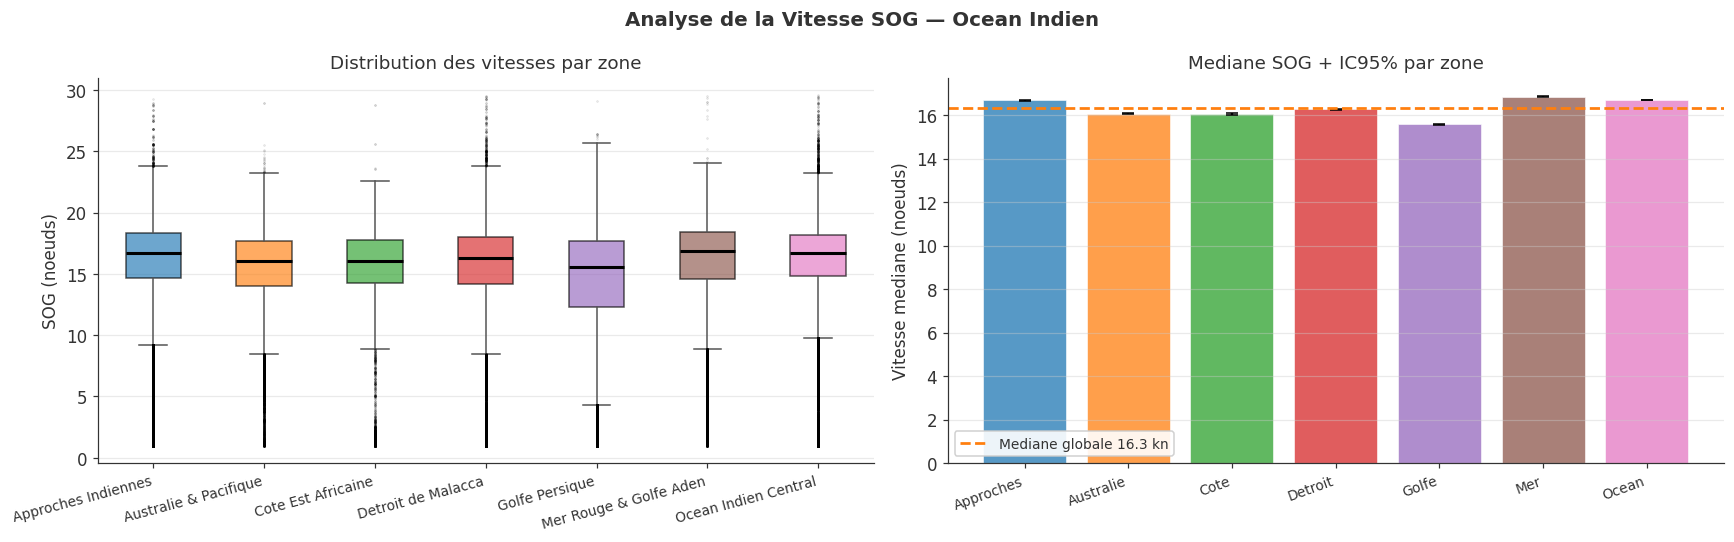

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplots
ax = axes[0]
data_z  = [df[df["zone"]==z]["sog"].values for z in zones_ord]
colors_z = [ZONE_COLORS[z] for z in zones_ord]
bp = ax.boxplot(data_z, patch_artist=True, notch=False,
                medianprops=dict(color="black", lw=2),
                whiskerprops=dict(color="#555555", lw=1),
                capprops=dict(color="#555555", lw=1),
                flierprops=dict(marker=".", markersize=1, alpha=0.15, color="#888888"))
for patch, c in zip(bp["boxes"], colors_z):
    patch.set_facecolor(c); patch.set_alpha(0.65)
ax.set_xticks(range(1, len(zones_ord)+1))
xlabels = [z.replace(" & ", " & ") for z in zones_ord]
ax.set_xticklabels(xlabels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("SOG (noeuds)")
ax.set_title("Distribution des vitesses par zone")
ax.grid(True, axis="y", alpha=0.4)

# Mediane + IC
ax2 = axes[1]
medians = [np.median(df[df["zone"]==z]["sog"].values) for z in zones_ord]
stds    = [df[df["zone"]==z]["sog"].std() for z in zones_ord]
ns      = [len(df[df["zone"]==z]) for z in zones_ord]
x = np.arange(len(zones_ord))
bars = ax2.bar(x, medians, color=colors_z, alpha=0.75, edgecolor="white", linewidth=0.5)
ax2.errorbar(x, medians, yerr=[1.96*s/n**0.5 for s,n in zip(stds,ns)],
             fmt="none", color="black", capsize=4, lw=1.5)
ax2.axhline(np.median(df["sog"]), color=C2, lw=1.8, ls="--",
            label=f"Mediane globale {np.median(df['sog']):.1f} kn")
ax2.set_xticks(x)
ax2.set_xticklabels([z.split()[0] for z in zones_ord], rotation=20, ha="right", fontsize=9)
ax2.set_ylabel("Vitesse mediane (noeuds)")
ax2.set_title("Mediane SOG + IC95% par zone")
ax2.legend(fontsize=9)
ax2.grid(True, axis="y", alpha=0.4)

fig.suptitle("Analyse de la Vitesse SOG — Ocean Indien", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_vitesse_boxplots.png")
plt.show()

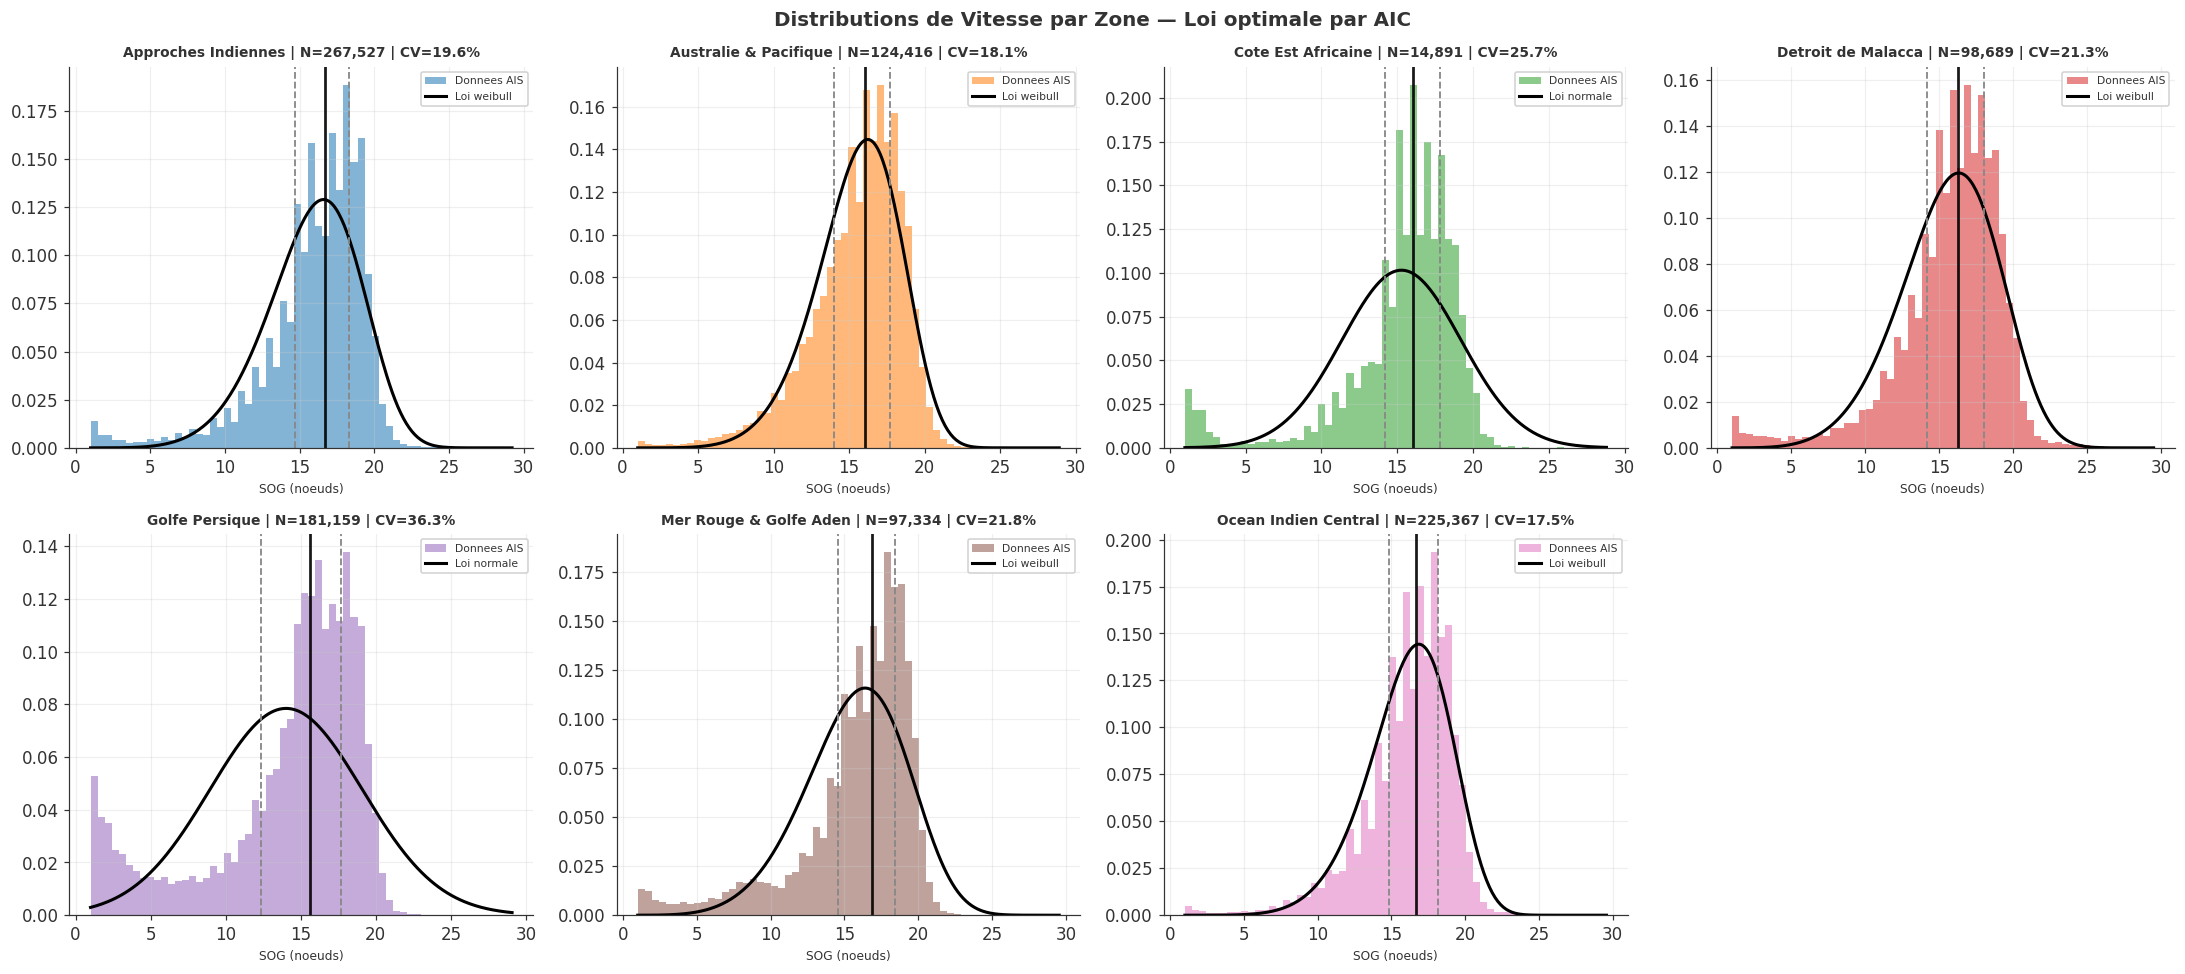

In [10]:
# Distributions par zone avec loi AIC
ncols, nrows = 4, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 9))
axes_flat = axes.flatten()

for k, zone in enumerate(zones_ord):
    ax = axes_flat[k]
    sog_z = df[df["zone"]==zone]["sog"].dropna().values
    sog_z = sog_z[(sog_z >= SOG_MIN) & (sog_z <= SOG_MAX)]
    color = ZONE_COLORS[zone]

    ax.hist(sog_z, bins=60, density=True, color=color, alpha=0.55,
            edgecolor="none", label="Donnees AIS")

    ln, lp = law_summary[zone]["loi"], law_summary[zone]["params"]
    x_r = np.linspace(sog_z.min(), sog_z.max(), 300)
    try:
        ax.plot(x_r, LAWS[ln].pdf(x_r, *lp), color="black", lw=2, label=f"Loi {ln}")
    except Exception:
        pass

    q1, med, q3 = np.percentile(sog_z, [25, 50, 75])
    ax.axvline(med, color="black", ls="-",  lw=1.8, alpha=0.9)
    ax.axvline(q1,  color="#888888", ls="--", lw=1.2)
    ax.axvline(q3,  color="#888888", ls="--", lw=1.2)

    cv = law_summary[zone]["std"] / law_summary[zone]["mean"] * 100
    title_txt = f"{zone} | N={len(sog_z):,} | CV={cv:.1f}%"
    ax.set_title(title_txt, fontsize=9, fontweight="bold")
    ax.set_xlabel("SOG (noeuds)", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes_flat[-1].set_visible(False)
fig.suptitle("Distributions de Vitesse par Zone — Loi optimale par AIC",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_distributions_zones.png")
plt.show()

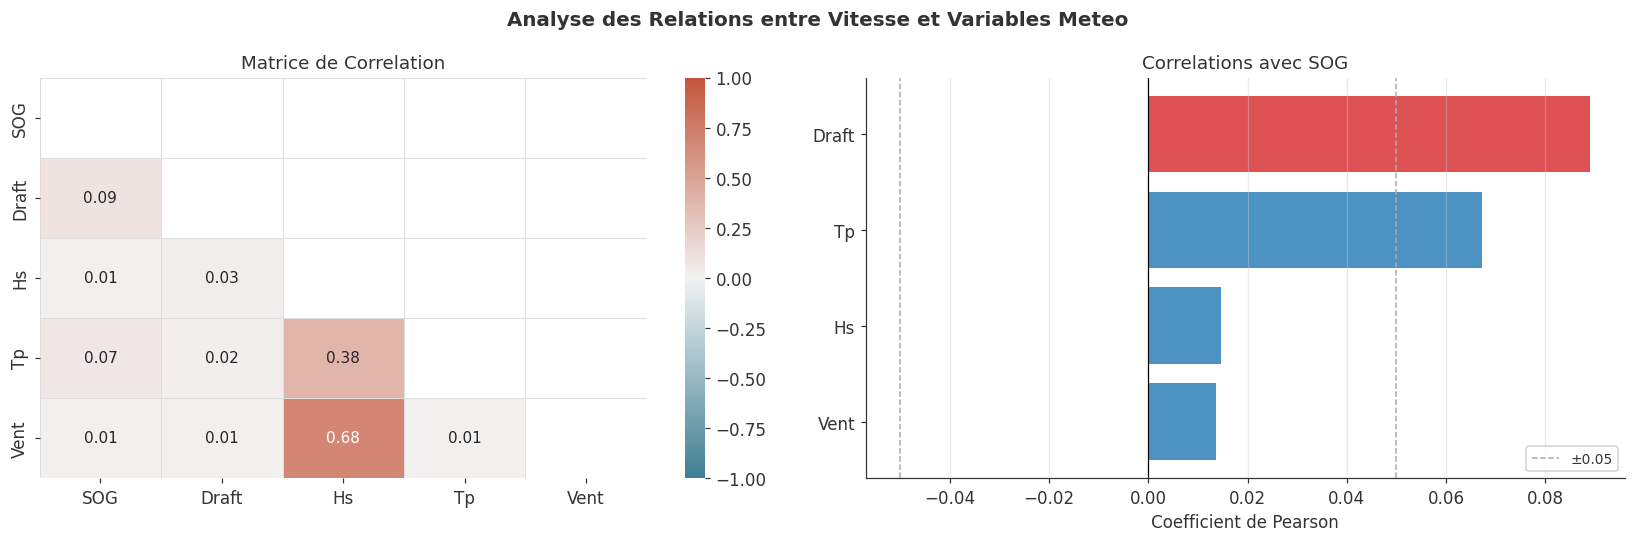

Correlations avec SOG :
draft                             0.089
wave period Tp (s)                0.067
significant wave height Hs (m)    0.015
wind_speed                        0.014
Name: sog, dtype: float64


In [11]:
# Correlations SOG / meteo
corr_cols = ["sog", "draft"]
if HAS_HS:             corr_cols += [HS_COL]
if TP_COL:             corr_cols += [TP_COL]
if "wind_speed" in df.columns: corr_cols += ["wind_speed"]
if "T_air_C"    in df.columns: corr_cols += ["T_air_C"]
if "T_mer_C"    in df.columns: corr_cols += ["T_mer_C"]
corr_cols = [c for c in corr_cols if c in df.columns]

labels_short = {"sog":"SOG","draft":"Draft","wind_speed":"Vent",
                "T_air_C":"T.air","T_mer_C":"T.mer"}
if HS_COL: labels_short[HS_COL] = "Hs"
if TP_COL: labels_short[TP_COL] = "Tp"

corr  = df[corr_cols].corr()
labels = [labels_short.get(c,c) for c in corr_cols]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.5, linecolor="#dddddd",
            ax=ax, xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 10})
ax.set_title("Matrice de Correlation")

# Barplot corr avec SOG
ax2 = axes[1]
corr_sog = corr["sog"].drop("sog").sort_values(key=abs, ascending=True)
bar_colors = [C4 if abs(v) > 0.08 else C1 for v in corr_sog.values]
ax2.barh([labels_short.get(c,c) for c in corr_sog.index], corr_sog.values,
         color=bar_colors, alpha=0.8)
ax2.axvline(0, color="black", lw=0.8)
ax2.axvline( 0.05, color="#aaaaaa", lw=1, ls="--")
ax2.axvline(-0.05, color="#aaaaaa", lw=1, ls="--", label="±0.05")
ax2.set_title("Correlations avec SOG")
ax2.set_xlabel("Coefficient de Pearson")
ax2.legend(fontsize=9)
ax2.grid(True, axis="x", alpha=0.4)

fig.suptitle("Analyse des Relations entre Vitesse et Variables Meteo",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_correlations.png")
plt.show()

print("Correlations avec SOG :")
print(corr["sog"].drop("sog").sort_values(key=abs,ascending=False).round(3))

### 2.x Fitting de la vitesse globale — Tout l'Océan Indien

**Demande réunion 30/03/2026 (Alistair) :** Fitter la distribution de vitesse sur
**l'ensemble de l'Océan Indien** (pas seulement par zone) pour obtenir une loi de référence
globale utile pour la modélisation ARMA et le ML.

On compare les quatre familles de lois candidates via AIC (Akaike Information Criterion).
Le critère AIC pénalise la complexité du modèle : **AIC = 2k − 2ℓ** où k = nombre de paramètres.


Fitting global — 919,937 observations de croisière
  Normale N(μ,σ)                AIC=     1006702.4  BIC=     1006722.8  μ=16.028  σ=2.998
  Log-normale LN(μ,σ)           AIC=     1076732.3  BIC=     1076762.9  μ=16.085  σ=3.713
  Gamma Γ(a,b)                  AIC=     1048538.5  BIC=     1048569.1  μ=16.028  σ=3.378
  Weibull W(c,λ)                AIC=      983407.5  BIC=      983438.1  μ=16.038  σ=2.778

✅ Meilleure loi (AIC minimal) : Weibull W(c,λ)
   μ = 16.038 nœuds  |  σ = 2.778 nœuds


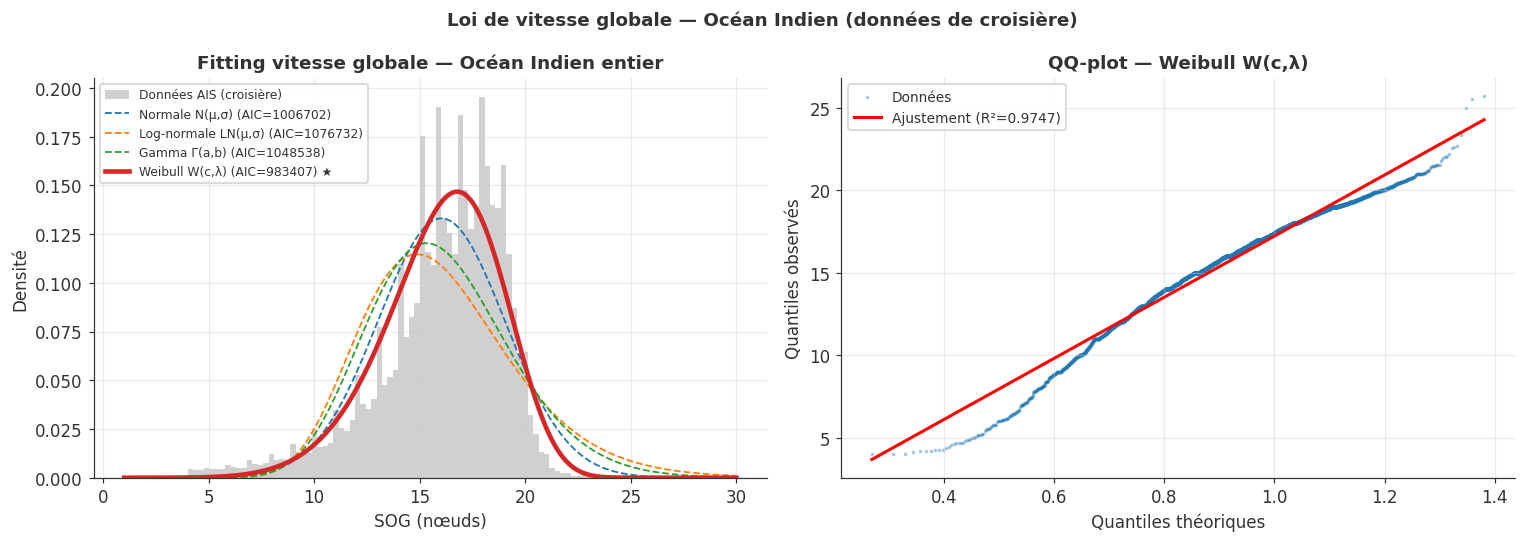

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Fitting vitesse globale sur tout l'Océan Indien
# Tâche réunion 30/03/2026 — Alistair (séries temporelles, pas les vitesses directement)
# ─────────────────────────────────────────────────────────────────────────────

# On travaille sur les données de croisière si disponibles, sinon df entier
df_fit_src = df_cruise if "df_cruise" in dir() else df

sog_global = df_fit_src["sog"].dropna().values
sog_global = sog_global[(sog_global >= SOG_MIN) & (sog_global <= SOG_MAX)]

print(f"Fitting global — {len(sog_global):,} observations de croisière")

# Fit des 4 lois candidates
LAWS_FIT = {
    "Normale N(μ,σ)":         (norm,        {}),
    "Log-normale LN(μ,σ)":    (lognorm,     {"floc": 0}),
    "Gamma Γ(a,b)":           (gamma,       {"floc": 0}),
    "Weibull W(c,λ)":         (weibull_min, {"floc": 0}),
}

results_fit = {}
sample = sog_global if len(sog_global) <= 200_000 else np.random.choice(sog_global, 200_000, replace=False)

for name, (dist, kw) in LAWS_FIT.items():
    try:
        params = dist.fit(sample, **kw)
        ll     = np.sum(dist.logpdf(sample, *params))
        aic    = 2*len(params) - 2*ll
        bic    = len(params)*np.log(len(sample)) - 2*ll
        mu     = float(dist.mean(*params))
        si     = float(dist.std(*params))
        results_fit[name] = {"params": params, "aic": aic, "bic": bic, "mean": mu, "std": si, "dist": dist}
        print(f"  {name:<28s}  AIC={aic:>14.1f}  BIC={bic:>14.1f}  μ={mu:.3f}  σ={si:.3f}")
    except Exception as e:
        print(f"  {name:<28s}  ERREUR: {e}")

best_name = min(results_fit, key=lambda k: results_fit[k]["aic"])
best      = results_fit[best_name]
print(f"\n✅ Meilleure loi (AIC minimal) : {best_name}")
print(f"   μ = {best['mean']:.3f} nœuds  |  σ = {best['std']:.3f} nœuds")

# ── Graphique ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(sog_global, bins=100, density=True, color="#aaaaaa", alpha=0.55,
        edgecolor="none", label="Données AIS (croisière)")
x = np.linspace(SOG_MIN, SOG_MAX, 500)
colors_laws = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]
for (name, res), col in zip(results_fit.items(), colors_laws):
    pdf = res["dist"].pdf(x, *res["params"])
    lw  = 3.0 if name == best_name else 1.2
    ls  = "-" if name == best_name else "--"
    ax.plot(x, pdf, color=col, lw=lw, ls=ls,
            label=f"{name} (AIC={res['aic']:.0f})" + (" ★" if name==best_name else ""))
ax.set_xlabel("SOG (nœuds)"); ax.set_ylabel("Densité")
ax.set_title("Fitting vitesse globale — Océan Indien entier", fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

# QQ-plot par rapport à la meilleure loi
ax2 = axes[1]
from scipy.stats import probplot
sub = np.random.choice(sog_global, min(5000, len(sog_global)), replace=False)
(osm, osr), (slope, intercept, r) = probplot(sub, dist=best["dist"],
                                              sparams=best["params"][:-2] if len(best["params"])>2 else best["params"],
                                              fit=True)
ax2.scatter(osm, osr, s=2, alpha=0.3, color="#1f77b4", label="Données")
ax2.plot(osm, slope*np.array(osm)+intercept, color="red", lw=2,
         label=f"Ajustement (R²={r**2:.4f})")
ax2.set_xlabel("Quantiles théoriques"); ax2.set_ylabel("Quantiles observés")
ax2.set_title(f"QQ-plot — {best_name}", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

fig.suptitle("Loi de vitesse globale — Océan Indien (données de croisière)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_global_speed_fit.png")
plt.show()

# Stockage pour usage en aval (ML features)
GLOBAL_SPEED_LAW  = best_name
GLOBAL_SPEED_MU   = best["mean"]
GLOBAL_SPEED_STD  = best["std"]


## 3. Etude de l'Acceleration

In [13]:
if "mmsi" in df.columns:
    df_sorted = df.sort_values(["mmsi","timestamp"]).copy()
    df_sorted["dt_h"]      = df_sorted.groupby("mmsi")["timestamp"].diff().dt.total_seconds()/3600
    df_sorted["dsog"]      = df_sorted.groupby("mmsi")["sog"].diff()
    df_sorted["accel"]     = df_sorted["dsog"] / df_sorted["dt_h"]
    df_sorted["accel_abs"] = df_sorted["accel"].abs()

    accel_clean = df_sorted[
        df_sorted["dt_h"].between(1/60, 6) &
        df_sorted["accel"].abs().between(0, 15)
    ]["accel"].dropna()

    print(f"Observations d'acceleration : {len(accel_clean):,}")
    print(f"  Mediane |accel| : {accel_clean.abs().median():.4f} kn/h")
    print(f"  Kurtosis        : {stats.kurtosis(accel_clean)+3:.1f}")
    print(f"  |accel| < 0.5   : {(accel_clean.abs() < 0.5).mean()*100:.1f}%")
else:
    print("Colonne mmsi absente")

Observations d'acceleration : 461,968
  Mediane |accel| : 0.1008 kn/h
  Kurtosis        : 87.2
  |accel| < 0.5   : 88.0%


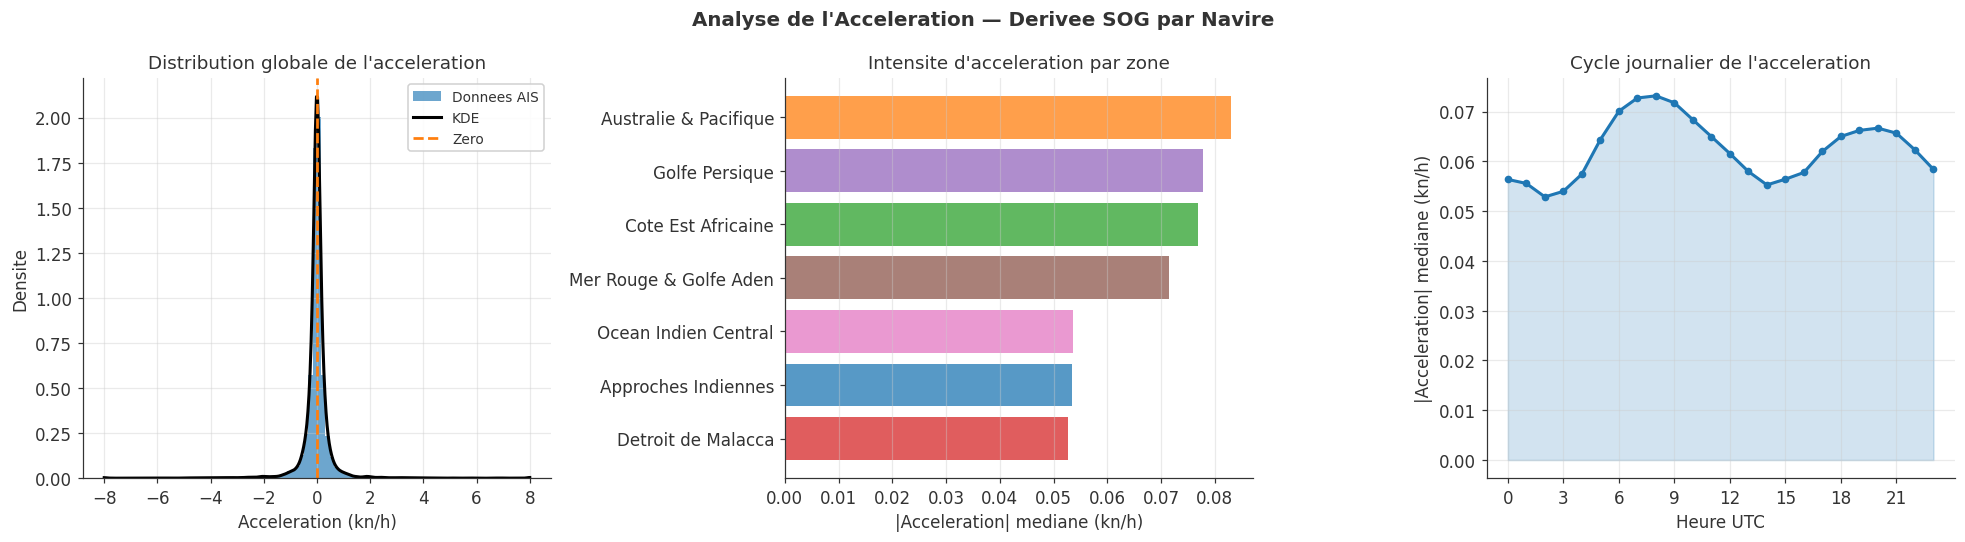

In [14]:
if "accel" in df_sorted.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Distribution globale
    ax = axes[0]
    clip = accel_clean.clip(-8, 8)
    ax.hist(clip, bins=100, density=True, color=C1, alpha=0.65, edgecolor="none",
            label="Donnees AIS")
    kde_x = np.linspace(-8, 8, 400)
    kde = stats.gaussian_kde(clip.sample(min(20000, len(clip)), random_state=42))
    ax.plot(kde_x, kde(kde_x), color="black", lw=2, label="KDE")
    ax.axvline(0, color=C2, lw=1.8, ls="--", label="Zero")
    ax.set_xlabel("Acceleration (kn/h)")
    ax.set_ylabel("Densite")
    ax.set_title("Distribution globale de l'acceleration")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

    # Mediane par zone
    ax2 = axes[1]
    df_sorted_z = df_sorted.dropna(subset=["accel","zone"])
    zone_accel = df_sorted_z.groupby("zone")["accel_abs"].median().sort_values()
    bar_cols2 = [ZONE_COLORS.get(z, C1) for z in zone_accel.index]
    ax2.barh(zone_accel.index, zone_accel.values, color=bar_cols2, alpha=0.75)
    ax2.set_xlabel("|Acceleration| mediane (kn/h)")
    ax2.set_title("Intensite d'acceleration par zone")
    ax2.grid(True, axis="x", alpha=0.4)

    # Cycle journalier
    ax3 = axes[2]
    accel_hr = df_sorted.dropna(subset=["accel"]).groupby("hour")["accel_abs"].median()
    ax3.plot(accel_hr.index, accel_hr.values, color=C1, lw=2, marker="o", ms=4)
    ax3.fill_between(accel_hr.index, accel_hr.values, alpha=0.2, color=C1)
    ax3.set_xlabel("Heure UTC")
    ax3.set_ylabel("|Acceleration| mediane (kn/h)")
    ax3.set_title("Cycle journalier de l'acceleration")
    ax3.set_xticks(range(0, 24, 3))
    ax3.grid(True, alpha=0.4)

    fig.suptitle("Analyse de l'Acceleration — Derivee SOG par Navire",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_acceleration.png")
    plt.show()

### 3.2 Carte spatiale de l'accélération

**Demande réunion 30/03/2026 :** Produire une **carte géographique de l'accélération** par carreau,
en complément de la distribution globale.

Cette carte permet d'identifier les zones de forte variabilité dynamique :
détroits, points de congestion, approches portuaires, zones météo difficiles.
Elle sera également utilisée comme **feature supplémentaire** pour le modèle ML (Section 8).


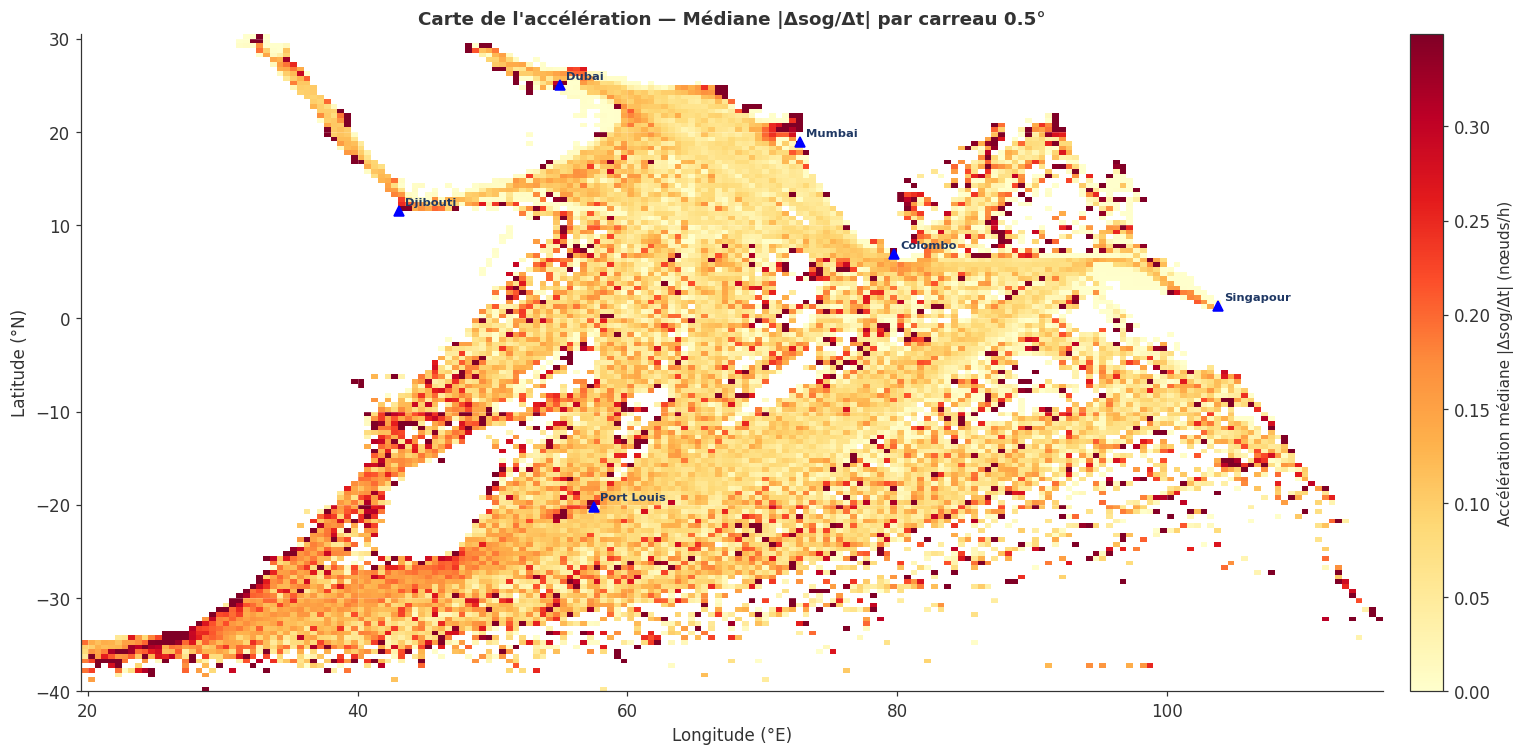

Nb cellules avec données accél. : 10,401
Médiane globale |accel| : 0.0928 nœuds/h
Cellule max : 7.1694 nœuds/h


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Carte spatiale de l'accélération — median |accel| par carreau 0.5°
# Tâche réunion 30/03/2026 (Équipe)
# ─────────────────────────────────────────────────────────────────────────────

if "accel" in df_sorted.columns:
    df_ac = df_sorted[
        df_sorted["dt_h"].between(1/60, 6) &
        df_sorted["accel"].abs().between(0, 15)
    ].copy()
    df_ac["cell_i"] = np.floor((df_ac["latitude"]  + 90.0)  / CELL_DEG).astype(int)
    df_ac["cell_j"] = np.floor((df_ac["longitude"] + 180.0) / CELL_DEG).astype(int)

    # Agrégation médiane |accel| par cellule
    accel_by_cell = (df_ac.groupby(["cell_i","cell_j"])["accel"]
                          .agg(lambda x: np.median(np.abs(x)))
                          .rename("median_accel_abs").reset_index())

    ci = accel_by_cell["cell_i"].values
    cj = accel_by_cell["cell_j"].values
    imin, imax = ci.min(), ci.max()
    jmin, jmax = cj.min(), cj.max()
    ni, nj = imax-imin+1, jmax-jmin+1

    mat_accel = np.full((ni, nj), np.nan)
    for _, row in accel_by_cell.iterrows():
        mat_accel[int(row.cell_i-imin), int(row.cell_j-jmin)] = row.median_accel_abs

    # Coordonnées géographiques des axes
    lat_edges = np.linspace(imin*CELL_DEG-90,  (imax+1)*CELL_DEG-90,  ni+1)
    lon_edges = np.linspace(jmin*CELL_DEG-180, (jmax+1)*CELL_DEG-180, nj+1)

    fig, ax = plt.subplots(figsize=(14, 7))
    pcm = ax.pcolormesh(lon_edges, lat_edges, mat_accel,
                        cmap="YlOrRd", vmin=0, vmax=np.nanpercentile(mat_accel, 95),
                        shading="auto")
    cbar = fig.colorbar(pcm, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Accélération médiane |Δsog/Δt| (nœuds/h)", fontsize=10)

    # Ports principaux
    PORTS_MAP = {"Djibouti":(11.5,43.1),"Mumbai":(18.9,72.8),
                 "Singapour":(1.3,103.8),"Dubai":(25.0,55.0),
                 "Colombo":(6.9,79.8),"Port Louis":(-20.2,57.5)}
    for port,(plat,plon) in PORTS_MAP.items():
        ax.plot(plon, plat, "b^", ms=7, zorder=5)
        ax.annotate(port, (plon, plat), textcoords="offset points",
                    xytext=(4,4), fontsize=7.5, color="#1f3864", fontweight="bold")

    ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
    ax.set_title("Carte de l'accélération — Médiane |Δsog/Δt| par carreau 0.5°",
                 fontweight="bold", fontsize=12)
    ax.grid(True, alpha=0.25, color="white", lw=0.5)
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_accel_map.png")
    plt.show()

    print(f"Nb cellules avec données accél. : {(~np.isnan(mat_accel)).sum():,}")
    print(f"Médiane globale |accel| : {np.nanmedian(mat_accel):.4f} nœuds/h")
    print(f"Cellule max : {np.nanmax(mat_accel):.4f} nœuds/h")

    # Sauvegarde pour usage ML
    accel_cell_dict = {
        (int(r.cell_i), int(r.cell_j)): r.median_accel_abs
        for _, r in accel_by_cell.iterrows()
    }
else:
    print("Données d'accélération absentes — recalculer la Section 3.1")
    accel_cell_dict = {}


## 4. Graphe de Popularite & Heatmaps

In [16]:
Node = tuple

def ll_to_cell(lat, lon):
    return (int(np.floor((lat+90)/CELL_DEG)), int(np.floor((lon+180)/CELL_DEG)))

def cell_to_ll(node):
    return ((node[0]+0.5)*CELL_DEG-90, (node[1]+0.5)*CELL_DEG-180)

def haversine_nm(lat1, lon1, lat2, lon2):
    R = 3440.065
    p1,p2 = np.radians(lat1), np.radians(lat2)
    dp,dl = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(np.clip(a,0,1)))

def cell_dist_nm(n1, n2):
    l1,l2 = cell_to_ll(n1), cell_to_ll(n2)
    return haversine_nm(l1[0],l1[1],l2[0],l2[1])

def neighbors_8(node):
    i,j = node
    return [(i+di,j+dj) for di in (-1,0,1) for dj in (-1,0,1) if (di,dj)!=(0,0)]

# Construction des aretes
ij_arr = df[["cell_i","cell_j"]].to_numpy()
keep   = np.ones(len(ij_arr), dtype=bool)
keep[1:] = np.any(ij_arr[1:]!=ij_arr[:-1], axis=1)
ij_c = ij_arr[keep]
i1,j1 = ij_c[:-1,0], ij_c[:-1,1]
i2,j2 = ij_c[1:,0],  ij_c[1:,1]
di,dj = np.abs(i2-i1), np.abs(j2-j1)
mask  = (di<=1)&(dj<=1)&~((di==0)&(dj==0))
edges = {}
for a,b,c,d in zip(i1[mask],j1[mask],i2[mask],j2[mask]):
    key = (int(a),int(b),int(c),int(d))
    edges[key] = edges.get(key,0)+1

# Construction de la grille
grid = {}
for (ci,cj), grp in df.groupby(["cell_i","cell_j"]):
    sog_arr = grp["sog"].dropna().to_numpy()
    ln,lp,mu,si = fit_best_law(sog_arr)
    hs_m = np.full(12,1.0)
    if HAS_HS:
        for m in range(1,13):
            sub = grp[grp["month"]==m][HS_COL].dropna()
            sub = sub[sub.between(0,15)]
            if len(sub)>=5: hs_m[m-1]=float(sub.median())
    grid[(int(ci),int(cj))] = {"sog":sog_arr,"law":ln,"params":lp,
                                "mean":mu,"std":si,"hs":hs_m,"count":len(sog_arr)}

print(f"{len(grid):,} cellules | {len(edges):,} aretes")

11,619 cellules | 2,128 aretes


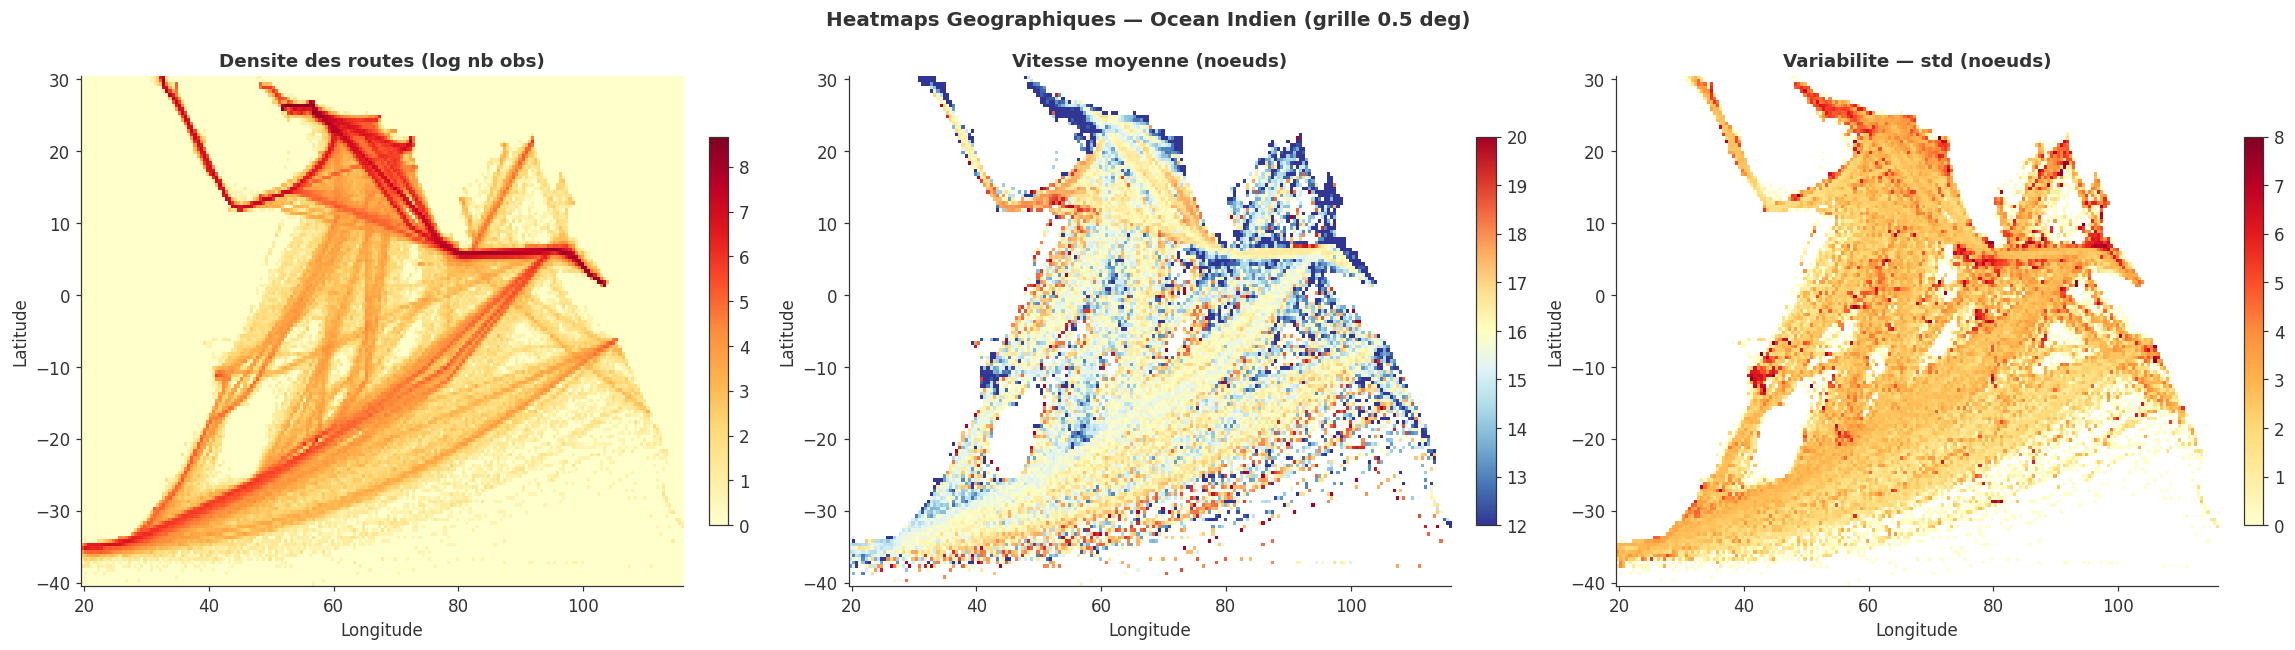

In [17]:
# Heatmaps : densite, vitesse moyenne, variabilite
i_vals = np.array([k[0] for k in grid]); j_vals = np.array([k[1] for k in grid])
imin,imax = i_vals.min(),i_vals.max()
jmin,jmax = j_vals.min(),j_vals.max()
ni,nj = imax-imin+1, jmax-jmin+1

mat_cnt  = np.zeros((ni,nj))
mat_mean = np.full((ni,nj), np.nan)
mat_std  = np.full((ni,nj), np.nan)
for (ci,cj), cell in grid.items():
    ri,rj = ci-imin, cj-jmin
    mat_cnt[ri,rj]  = cell["count"]
    mat_mean[ri,rj] = cell["mean"]
    mat_std[ri,rj]  = cell["std"]

extent = [jmin*CELL_DEG-180,(jmax+1)*CELL_DEG-180,
          imin*CELL_DEG-90, (imax+1)*CELL_DEG-90]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
configs = [
    (np.log1p(mat_cnt), "Densite des routes (log nb obs)", "YlOrRd", None),
    (mat_mean,          "Vitesse moyenne (noeuds)",         "RdYlBu_r", (12,20)),
    (mat_std,           "Variabilite — std (noeuds)",       "YlOrRd",   (0,8)),
]
for ax, (data, title, cmap, vl) in zip(axes, configs):
    kw = {} if vl is None else {"vmin":vl[0],"vmax":vl[1]}
    im = ax.imshow(data, origin="lower", aspect="auto", cmap=cmap, extent=extent, **kw)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

fig.suptitle("Heatmaps Geographiques — Ocean Indien (grille 0.5 deg)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_heatmaps.png")
plt.show()

### 4.2 Routes principales — Analyse par tranches de densité

**Demande réunion 30/03/2026 :** Au lieu d'un seul seuil pour les routes principales,
utiliser **plusieurs tranches de densité** (quantiles) pour visualiser la hiérarchie des routes :
corridors majeurs (très haute densité), routes secondaires, zones d'exploration.

Cette approche est directement liée au transfert d'information vers le ML :
l'**appartenance d'un point à une tranche de densité** sera une feature du modèle.


Nombre de cellules du graphe : 1,093
Densité médiane : 3  |  max : 178

Seuils de densité par tranche :
  Mineures (Q50-Q75)                            [     3 –        8]    257 cellules
  Secondaires (Q75-Q90)                         [     8 –       26]    195 cellules
  Principales (Q90-Q99)                         [    26 –      117]    100 cellules
  Corridors majeurs (>Q99)                      [   117 –      179]     11 cellules


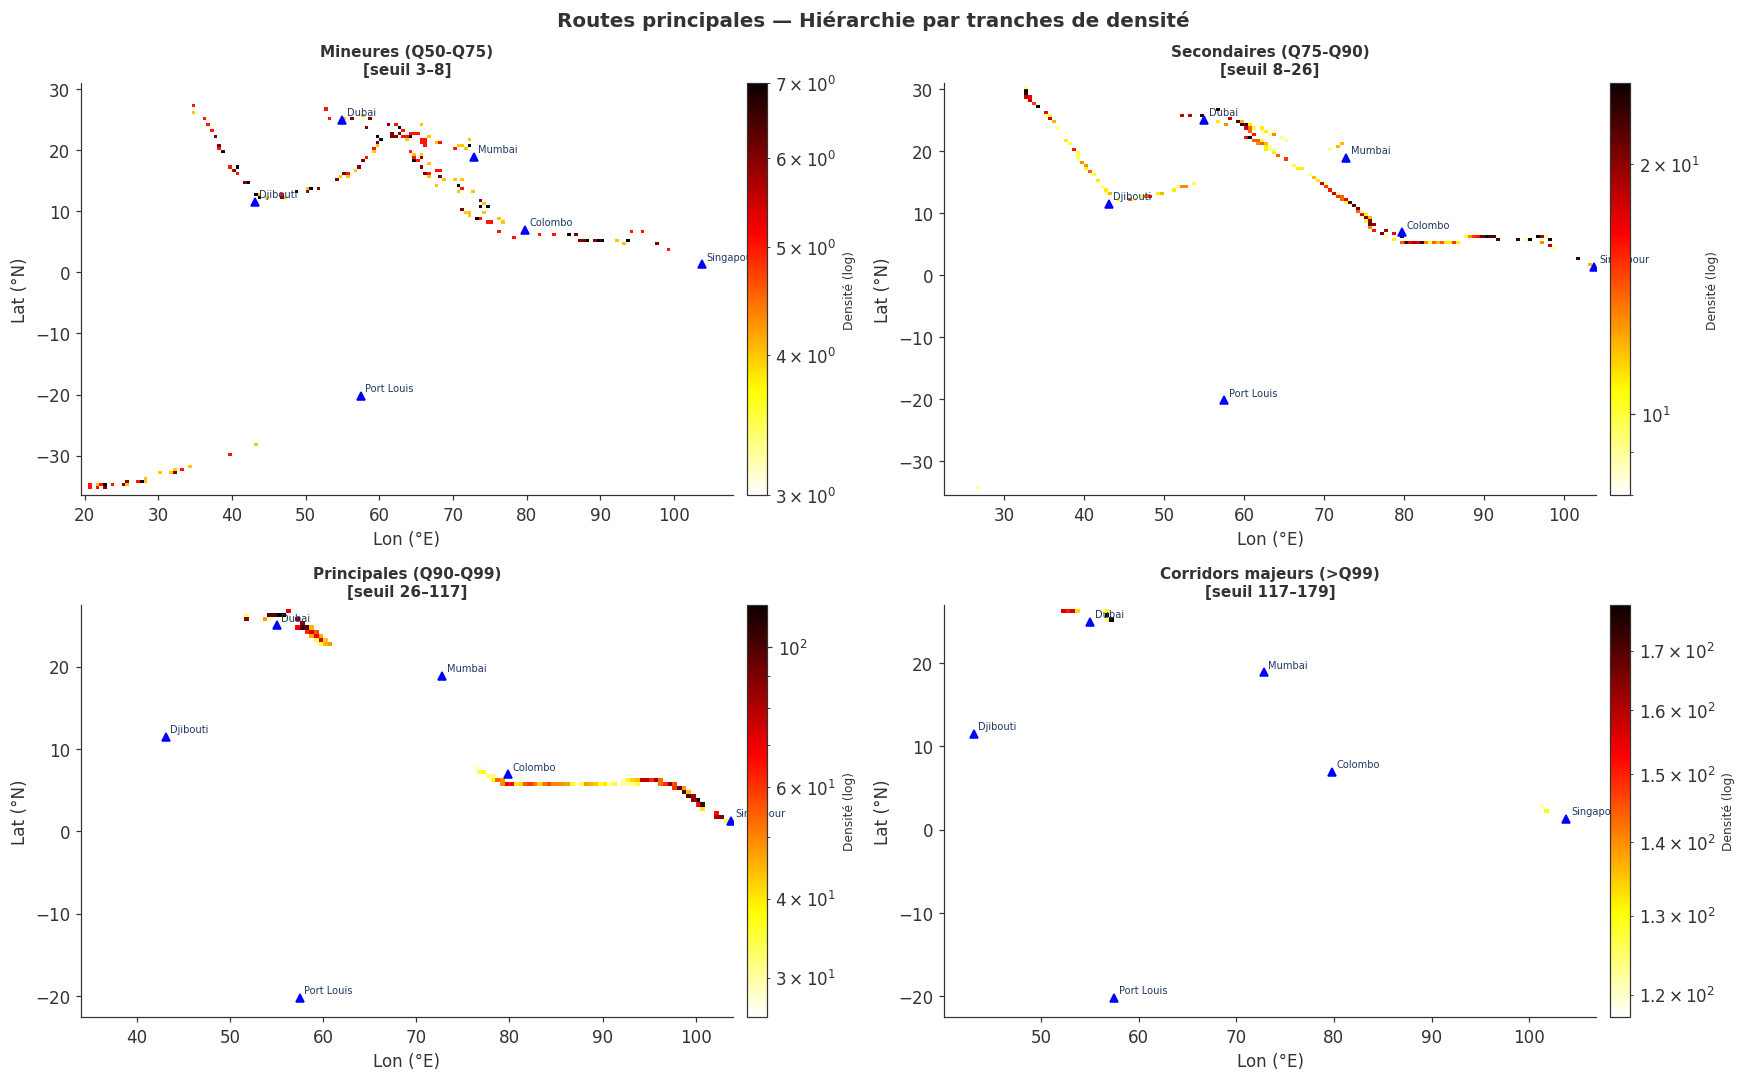


Features density_class et cell_density ajoutées au DataFrame
density_class
0    371224
1    128660
2    205941
3    251193
4     52365
Name: count, dtype: int64


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Routes principales par classe de seuils / tranches de densité
# Tâche réunion 30/03/2026 (Équipe)
# ─────────────────────────────────────────────────────────────────────────────

# Agrégation densité par cellule (nombre d'arêtes passant par chaque nœud)
cell_density = {}
for (ci, cj, di, dj), cnt in edges.items():
    for node in [(ci,cj),(di,dj)]:
        cell_density[node] = cell_density.get(node, 0) + cnt

if len(cell_density) == 0:
    print("Graphe non disponible — reconstruire la Section 4")
else:
    densities = np.array(list(cell_density.values()))
    print(f"Nombre de cellules du graphe : {len(cell_density):,}")
    print(f"Densité médiane : {np.median(densities):.0f}  |  max : {densities.max():.0f}")

    # Définition des tranches (quantiles 50%, 75%, 90%, 99%)
    TRANCHES = {
        "Mineures (Q50-Q75)": (np.percentile(densities,50), np.percentile(densities,75)),
        "Secondaires (Q75-Q90)": (np.percentile(densities,75), np.percentile(densities,90)),
        "Principales (Q90-Q99)": (np.percentile(densities,90), np.percentile(densities,99)),
        "Corridors majeurs (>Q99)":  (np.percentile(densities,99), densities.max()+1),
    }
    TRANCHE_COLORS = ["#aec7e8","#1f77b4","#ff7f0e","#d62728"]
    TRANCHE_LABELS = list(TRANCHES.keys())

    print("\nSeuils de densité par tranche :")
    for name, (lo, hi) in TRANCHES.items():
        cells_in = [(k,v) for k,v in cell_density.items() if lo <= v < hi]
        print(f"  {name.replace(chr(10),' '):<45s} [{lo:>6.0f} – {hi:>8.0f}]  "
              f"{len(cells_in):>5} cellules")

    # Visualisation : 4 cartes côte à côte
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes_flat = axes.flatten()

    for ax, (name, (lo, hi)), col in zip(axes_flat, TRANCHES.items(), TRANCHE_COLORS):
        # Matrices de densité pour cette tranche
        cells_tranche = {k: v for k, v in cell_density.items() if lo <= v < hi}
        if not cells_tranche:
            ax.text(0.5, 0.5, "Pas de données", transform=ax.transAxes, ha="center")
            continue

        ci_t = np.array([k[0] for k in cells_tranche])
        cj_t = np.array([k[1] for k in cells_tranche])
        ni_t = int(ci_t.max()-ci_t.min()+3)
        nj_t = int(cj_t.max()-cj_t.min()+3)
        imin_t = int(ci_t.min()-1)
        jmin_t = int(cj_t.min()-1)

        mat_t = np.zeros((ni_t, nj_t))
        for (ci_, cj_), cnt_ in cells_tranche.items():
            ri, rj = int(ci_-imin_t), int(cj_-jmin_t)
            if 0 <= ri < ni_t and 0 <= rj < nj_t:
                mat_t[ri, rj] = cnt_

        lat_e = np.linspace(imin_t*CELL_DEG-90,  (imin_t+ni_t)*CELL_DEG-90,  ni_t+1)
        lon_e = np.linspace(jmin_t*CELL_DEG-180, (jmin_t+nj_t)*CELL_DEG-180, nj_t+1)

        from matplotlib.colors import LogNorm
        mat_plot = np.where(mat_t > 0, mat_t, np.nan)
        pcm = ax.pcolormesh(lon_e, lat_e, mat_plot,
                            cmap="hot_r",
                            norm=LogNorm(vmin=max(1, lo), vmax=max(2, hi-1)),
                            shading="auto")
        fig.colorbar(pcm, ax=ax, fraction=0.03, pad=0.02).set_label("Densité (log)", fontsize=8)

        # Ports
        for port,(plat,plon) in PORTS_MAP.items():
            ax.plot(plon, plat, "b^", ms=5, zorder=5)
            ax.annotate(port, (plon,plat), textcoords="offset points",
                        xytext=(3,3), fontsize=6.5, color="#1f3864")

        ax.set_title(f"{name}\n[seuil {lo:.0f}–{hi:.0f}]",
                     fontweight="bold", fontsize=10)
        ax.set_xlabel("Lon (°E)"); ax.set_ylabel("Lat (°N)")
        ax.grid(True, alpha=0.2, color="white", lw=0.5)

    fig.suptitle("Routes principales — Hiérarchie par tranches de densité",
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_routes_par_seuils.png")
    plt.show()

    # ── Attribution d'une tranche de densité à chaque observation ─────────────
    # (sera utilisé comme feature ML en Section 8)
    def get_density_class(cell_i, cell_j):
        d = cell_density.get((cell_i, cell_j), 0)
        for k, (name, (lo, hi)) in enumerate(TRANCHES.items()):
            if lo <= d < hi:
                return k + 1
        return 0

    if "cell_i" in df.columns:
        df["density_class"] = df.apply(
            lambda r: get_density_class(int(r.cell_i), int(r.cell_j)), axis=1
        )
        df["cell_density"]  = df.apply(
            lambda r: cell_density.get((int(r.cell_i), int(r.cell_j)), 0), axis=1
        )
        print(f"\nFeatures density_class et cell_density ajoutées au DataFrame")
        print(df["density_class"].value_counts().sort_index())


## 5. Dijkstra & Calibration du parametre alpha

In [19]:
def dijkstra(start_ll, end_ll, alpha=ALPHA):
    src,dst = ll_to_cell(*start_ll), ll_to_cell(*end_ll)
    if src==dst: return [src],0.0
    dist_to={src:0.0}; prev={src:None}; heap=[(0.0,src)]
    while heap:
        cost_u,u = heapq.heappop(heap)
        if u==dst:
            path=[]; cur=dst
            while cur is not None: path.append(cur); cur=prev[cur]
            return list(reversed(path)), cost_u
        if cost_u > dist_to.get(u,np.inf): continue
        for v in neighbors_8(u):
            if v not in grid: continue
            cnt  = edges.get((u[0],u[1],v[0],v[1]),1)
            cost = cell_dist_nm(u,v)/(cnt**alpha)
            nc   = cost_u+cost
            if nc < dist_to.get(v,np.inf):
                dist_to[v]=nc; prev[v]=u
                heapq.heappush(heap,(nc,v))
    return None,np.inf

PORTS = {"Djibouti":(11.5,43.1),"Mumbai":(18.9,72.8),
         "Singapour":(1.3,103.8),"Dubai":(25.0,55.0),"Colombo":(6.9,79.8)}

path_t,_ = dijkstra(PORTS["Djibouti"], PORTS["Mumbai"])
if path_t:
    d = sum(cell_dist_nm(path_t[k],path_t[k+1]) for k in range(len(path_t)-1))
    print(f"Djibouti -> Mumbai : {len(path_t)} cellules, {d:.0f} nm")

Djibouti -> Mumbai : 60 cellules, 1877 nm


In [20]:
def sample_speed(cell_d, n, month=6):
    try:
        s = LAWS.get(cell_d["law"],norm).rvs(*cell_d["params"], size=n)
    except Exception:
        s = np.random.normal(cell_d["mean"], cell_d["std"], size=n)
    if HAS_HS and 1<=month<=12:
        hs = cell_d["hs"][month-1]
        if hs > HS_SEUIL:
            s *= SLOW_BASE**((hs-HS_SEUIL)/HS_SEUIL)
    return np.clip(s, SOG_MIN, SOG_MAX)

def mc_eta(start_ll, end_ll, alpha=ALPHA, month=6, n_mc=2000):
    path,_ = dijkstra(start_ll, end_ll, alpha)
    if path is None or len(path)<2: return None
    dists = [cell_dist_nm(path[k],path[k+1]) for k in range(len(path)-1)]
    T = np.zeros(n_mc)
    for k,node in enumerate(path[:-1]):
        cell_d = grid.get(node, {"law":"normale","params":(15.5,3.0),
                                  "mean":15.5,"std":3.0,"hs":np.ones(12)})
        v = sample_speed(cell_d, n_mc, month)
        T += dists[k]*1852 / np.clip(v*0.5144, 0.1, 30)
    return T/3600

# Calibration alpha
ALPHAS = np.arange(0, 2.05, 0.05)
VOYAGES_TEST = [
    (PORTS["Djibouti"], PORTS["Mumbai"],  115),
    (PORTS["Dubai"],    PORTS["Mumbai"],   90),
    (PORTS["Djibouti"], PORTS["Colombo"], 105),
]
alpha_err, alpha_p10 = [], []
for a in ALPHAS:
    errs=[]; p10=0
    for s,e,eta_r in VOYAGES_TEST:
        T = mc_eta(s,e,alpha=a,n_mc=500)
        if T is not None:
            pred = np.median(T)
            pct  = abs(pred-eta_r)/eta_r*100
            errs.append(pct)
            if pct<=10: p10+=1
    alpha_err.append(np.mean(errs) if errs else np.nan)
    alpha_p10.append(p10/len(VOYAGES_TEST)*100 if errs else np.nan)

best_a   = ALPHAS[np.nanargmin(alpha_err)]
best_err = np.nanmin(alpha_err)
print(f"alpha optimal : {best_a:.2f} (erreur {best_err:.1f}%)")

alpha optimal : 0.20 (erreur 20.5%)


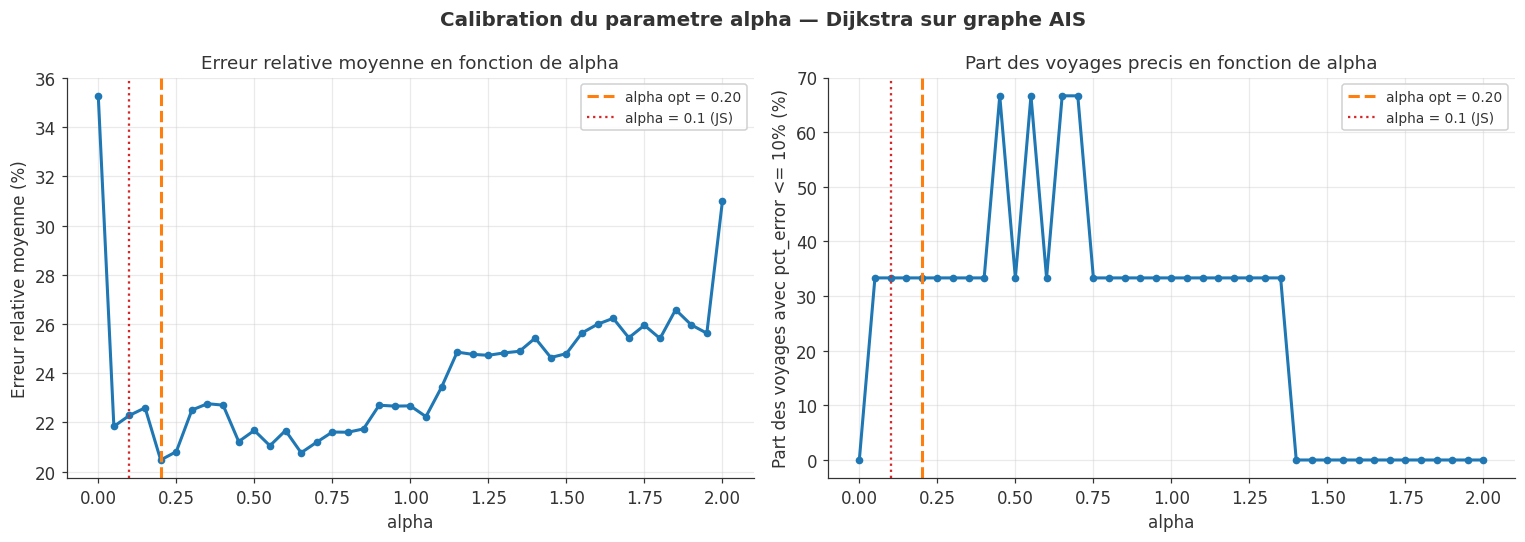

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ALPHAS, alpha_err, color=C1, lw=2, marker="o", ms=4)
ax.axvline(best_a, color=C2, lw=2, ls="--", label=f"alpha opt = {best_a:.2f}")
ax.axvline(0.1, color=C4, lw=1.5, ls=":", label="alpha = 0.1 (JS)")
ax.set_xlabel("alpha")
ax.set_ylabel("Erreur relative moyenne (%)")
ax.set_title("Erreur relative moyenne en fonction de alpha")
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

ax2 = axes[1]
ax2.plot(ALPHAS, alpha_p10, color=C1, lw=2, marker="o", ms=4)
ax2.axvline(best_a, color=C2, lw=2, ls="--", label=f"alpha opt = {best_a:.2f}")
ax2.axvline(0.1, color=C4, lw=1.5, ls=":", label="alpha = 0.1 (JS)")
ax2.set_xlabel("alpha")
ax2.set_ylabel("Part des voyages avec pct_error <= 10% (%)")
ax2.set_title("Part des voyages precis en fonction de alpha")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

fig.suptitle("Calibration du parametre alpha — Dijkstra sur graphe AIS",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_courbe_alpha.png")
plt.show()

## 6. Modele ETA Monte Carlo

In [22]:
TRAJETS = [
    ("Djibouti","Mumbai",  6, "Mousson d'ete"),
    ("Djibouti","Mumbai",  1, "Hiver calme"),
    ("Dubai",   "Mumbai",  9, "Golfe Persique -> Inde"),
]

results = {}
print(f"{'Trajet':<35s} {'Dist':>6} {'Med(h)':>8} {'IC10':>8} {'IC90':>8}")
print("-"*70)
for dep,arr,mois,label in TRAJETS:
    T = mc_eta(PORTS[dep], PORTS[arr], alpha=ALPHA, month=mois, n_mc=N_MC)
    if T is not None:
        path_t,_ = dijkstra(PORTS[dep], PORTS[arr])
        d = sum(cell_dist_nm(path_t[k],path_t[k+1]) for k in range(len(path_t)-1)) if path_t else 0
        results[f"{dep}->{arr}(m{mois})"] = {"T":T,"dist":d,"label":label}
        med  = np.median(T)
        ic10,ic90 = np.percentile(T,[10,90])
        print(f"  {dep}->{arr} ({label}) {d:>7.0f} {med:>8.1f} {ic10:>8.1f} {ic90:>8.1f}")

Trajet                                Dist   Med(h)     IC10     IC90
----------------------------------------------------------------------


  Djibouti->Mumbai (Mousson d'ete)    1877    123.3    117.8    142.1
  Djibouti->Mumbai (Hiver calme)    1877    121.5    116.1    140.0
  Dubai->Mumbai (Golfe Persique -> Inde)    1142    109.9     96.0    132.1


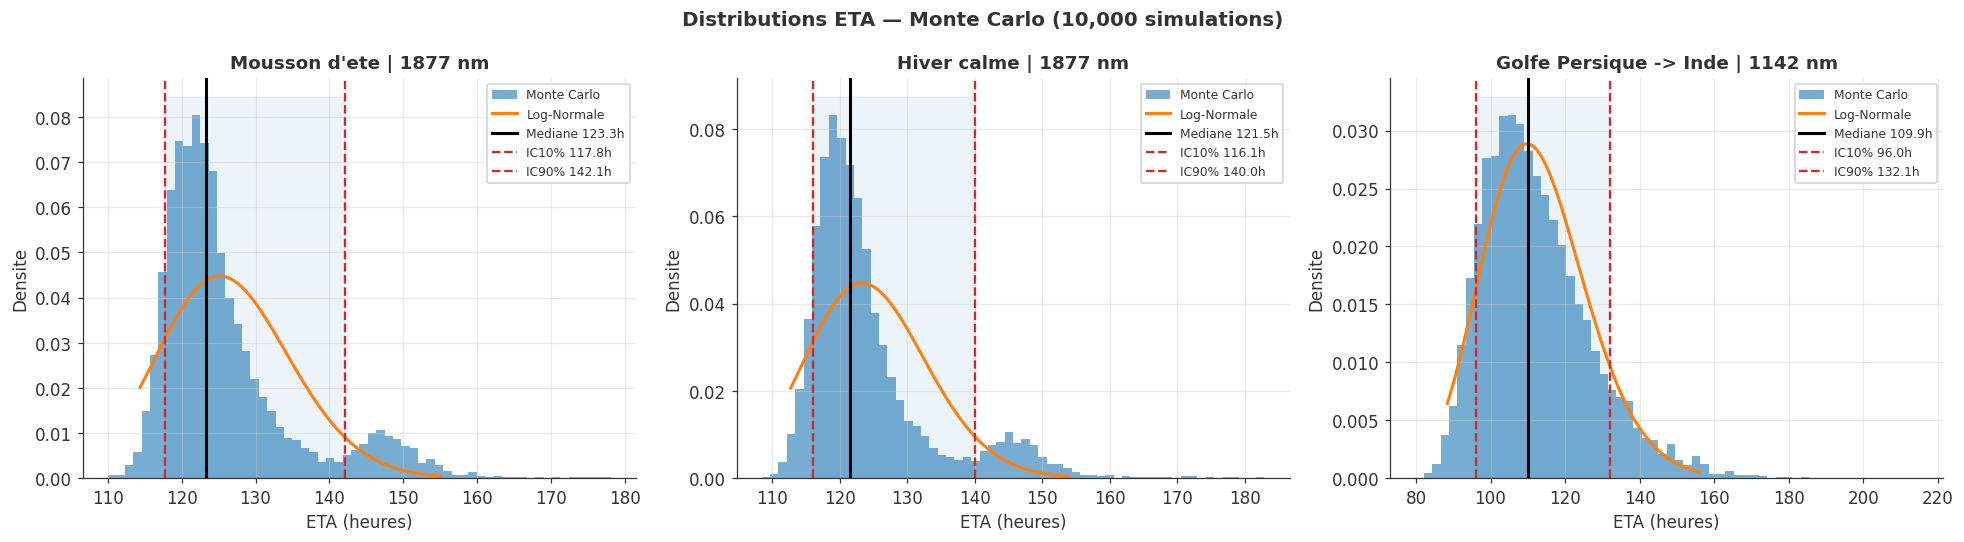

In [23]:
n_res = min(len(results), 3)
fig, axes = plt.subplots(1, n_res, figsize=(6*n_res, 5))
if n_res==1: axes=[axes]

for ax, (key,res) in zip(axes, list(results.items())[:n_res]):
    T = res["T"]
    med  = np.median(T)
    ic10 = np.percentile(T,10)
    ic90 = np.percentile(T,90)

    ax.hist(T, bins=60, density=True, color=C1, alpha=0.60,
            edgecolor="none", label="Monte Carlo")
    try:
        mu_l = np.log(np.clip(T,0.01,None)).mean()
        si_l = np.log(np.clip(T,0.01,None)).std()
        x_r  = np.linspace(np.percentile(T,1), np.percentile(T,99), 300)
        ax.plot(x_r, stats.lognorm.pdf(x_r, s=si_l, scale=np.exp(mu_l)),
                color=C2, lw=2, label="Log-Normale")
    except Exception:
        pass

    ax.axvline(med,  color="black", lw=2, ls="-",  label=f"Mediane {med:.1f}h")
    ax.axvline(ic10, color=C4,      lw=1.5, ls="--", label=f"IC10% {ic10:.1f}h")
    ax.axvline(ic90, color=C4,      lw=1.5, ls="--", label=f"IC90% {ic90:.1f}h")
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 0.01],
                     ic10, ic90, color=C1, alpha=0.08)
    ax.set_xlabel("ETA (heures)")
    ax.set_ylabel("Densite")
    ax.set_title(f"{res['label']} | {res['dist']:.0f} nm", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

fig.suptitle(f"Distributions ETA — Monte Carlo ({N_MC:,} simulations)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_eta_distributions.png")
plt.show()

## 7. Series Temporelles — STL + ARMA

In [24]:
# Serie temporelle hebdomadaire — on filtre les semaines vides pour eviter les trous
ts_weekly = (df.set_index("timestamp")["sog"]
               .resample("W").agg(["mean","std","count"]))
ts_weekly.columns = ["mean","std","count"]
ts_weekly = ts_weekly[ts_weekly["count"] >= 10].dropna(subset=["mean"])

# On supprime les eventuels trous (periodes sans donnees)
# en reindexant seulement sur les semaines effectivement observees
ts_weekly = ts_weekly.dropna(subset=["mean"])

print(f"Serie temporelle : {len(ts_weekly)} semaines")
print(f"  {ts_weekly.index[0].date()} -> {ts_weekly.index[-1].date()}")
print(f"  SOG moyen global : {ts_weekly['mean'].mean():.2f} noeuds")

Serie temporelle : 693 semaines
  2012-01-01 -> 2025-04-06
  SOG moyen global : 15.57 noeuds


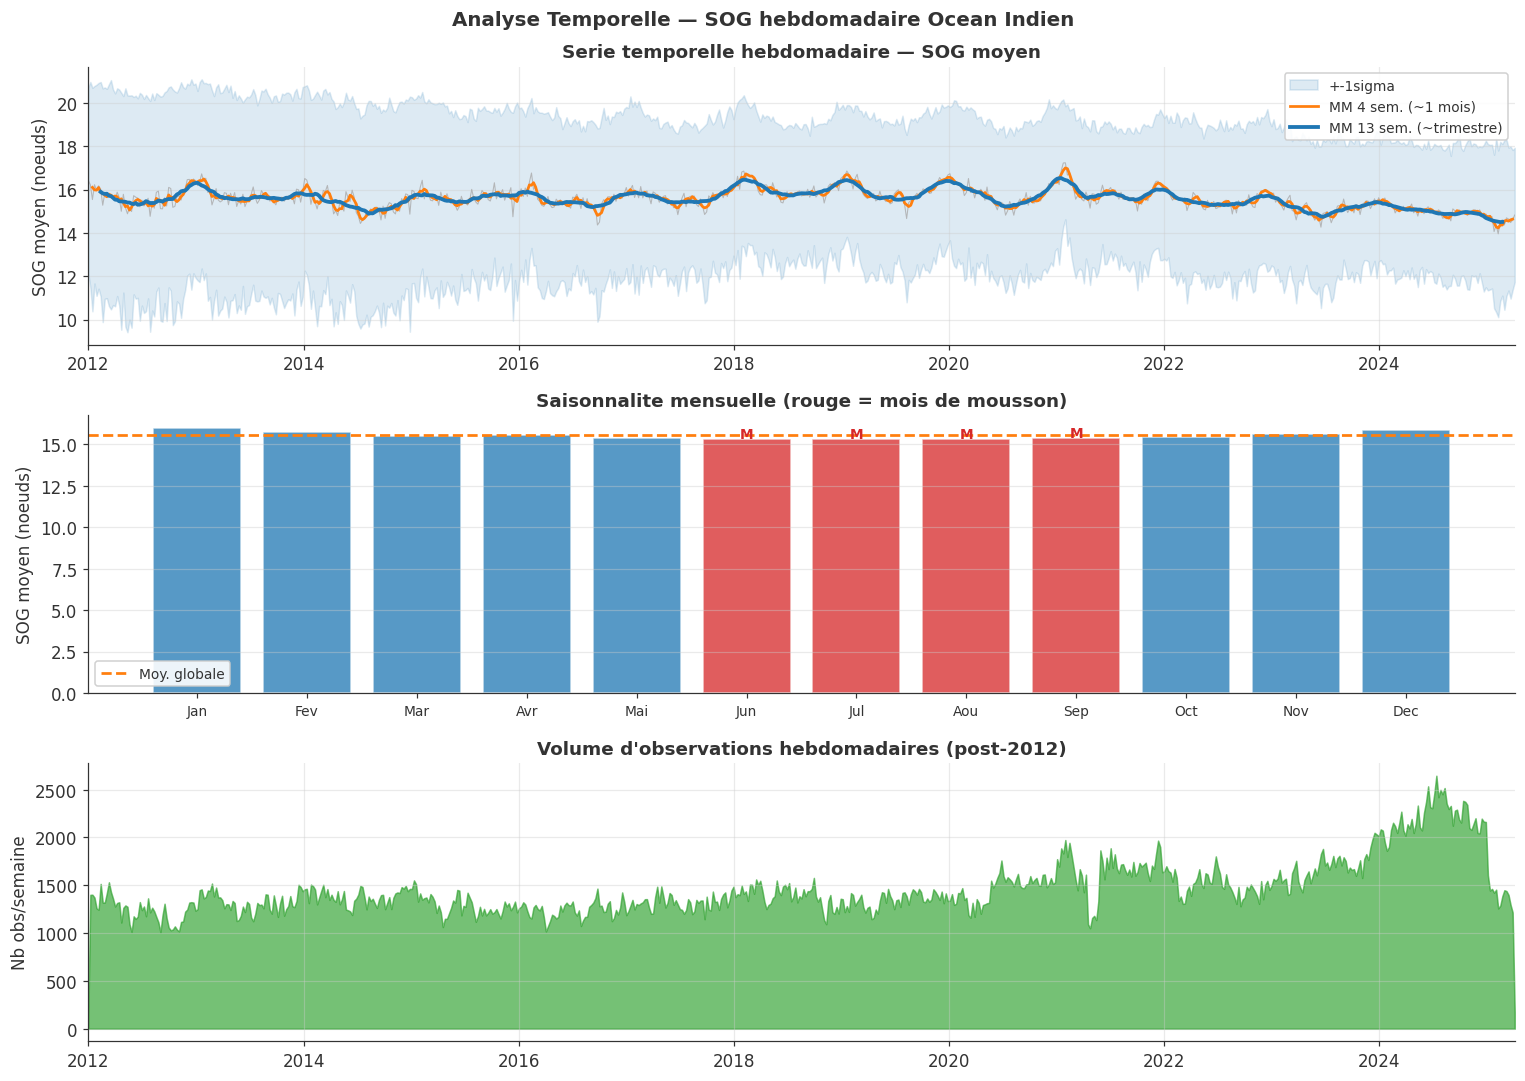

In [25]:
# Graphique serie temporelle — sans trous visuels a gauche
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

# Panneau 1 : serie hebdomadaire sur les dates effectives
ax = axes[0]
ax.plot(ts_weekly.index, ts_weekly["mean"], color="#aaaaaa", lw=0.7, alpha=0.8)
ax.fill_between(ts_weekly.index,
                ts_weekly["mean"]-ts_weekly["std"],
                ts_weekly["mean"]+ts_weekly["std"],
                color=C1, alpha=0.15, label="+-1sigma")
mm4  = ts_weekly["mean"].rolling(4,  center=True).mean()
mm13 = ts_weekly["mean"].rolling(13, center=True).mean()
ax.plot(ts_weekly.index, mm4,  color=C2, lw=1.8, label="MM 4 sem. (~1 mois)")
ax.plot(ts_weekly.index, mm13, color=C1, lw=2.5, label="MM 13 sem. (~trimestre)")
ax.set_xlim(ts_weekly.index[0], ts_weekly.index[-1])
ax.set_ylabel("SOG moyen (noeuds)")
ax.set_title("Serie temporelle hebdomadaire — SOG moyen", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

# Panneau 2 : saisonnalite mensuelle
ax2 = axes[1]
sog_m = df.groupby("month")["sog"].mean()
MOIS  = ["Jan","Fev","Mar","Avr","Mai","Jun","Jul","Aou","Sep","Oct","Nov","Dec"]
bar_colors = [C4 if m in [6,7,8,9] else C1 for m in range(1,13)]
ax2.bar(range(1,13), sog_m.values, color=bar_colors, alpha=0.75, edgecolor="white")
ax2.axhline(sog_m.mean(), color=C2, lw=1.8, ls="--", label="Moy. globale")
ax2.set_xticks(range(1,13)); ax2.set_xticklabels(MOIS, fontsize=9)
ax2.set_ylabel("SOG moyen (noeuds)")
ax2.set_title("Saisonnalite mensuelle (rouge = mois de mousson)", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(True, axis="y", alpha=0.4)
for m in [6,7,8,9]:
    ax2.text(m, sog_m[m]+0.04, "M", ha="center", color=C4, fontsize=9, fontweight="bold")

# Panneau 3 : volume d'observations
ax3 = axes[2]
ax3.fill_between(ts_weekly.index, ts_weekly["count"], color=C3, alpha=0.65)
ax3.set_xlim(ts_weekly.index[0], ts_weekly.index[-1])
ax3.set_ylabel("Nb obs/semaine")
ax3.set_title("Volume d'observations hebdomadaires (post-2012)", fontweight="bold")
ax3.grid(True, alpha=0.4)

fig.suptitle("Analyse Temporelle — SOG hebdomadaire Ocean Indien",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_serie_temporelle.png")
plt.show()

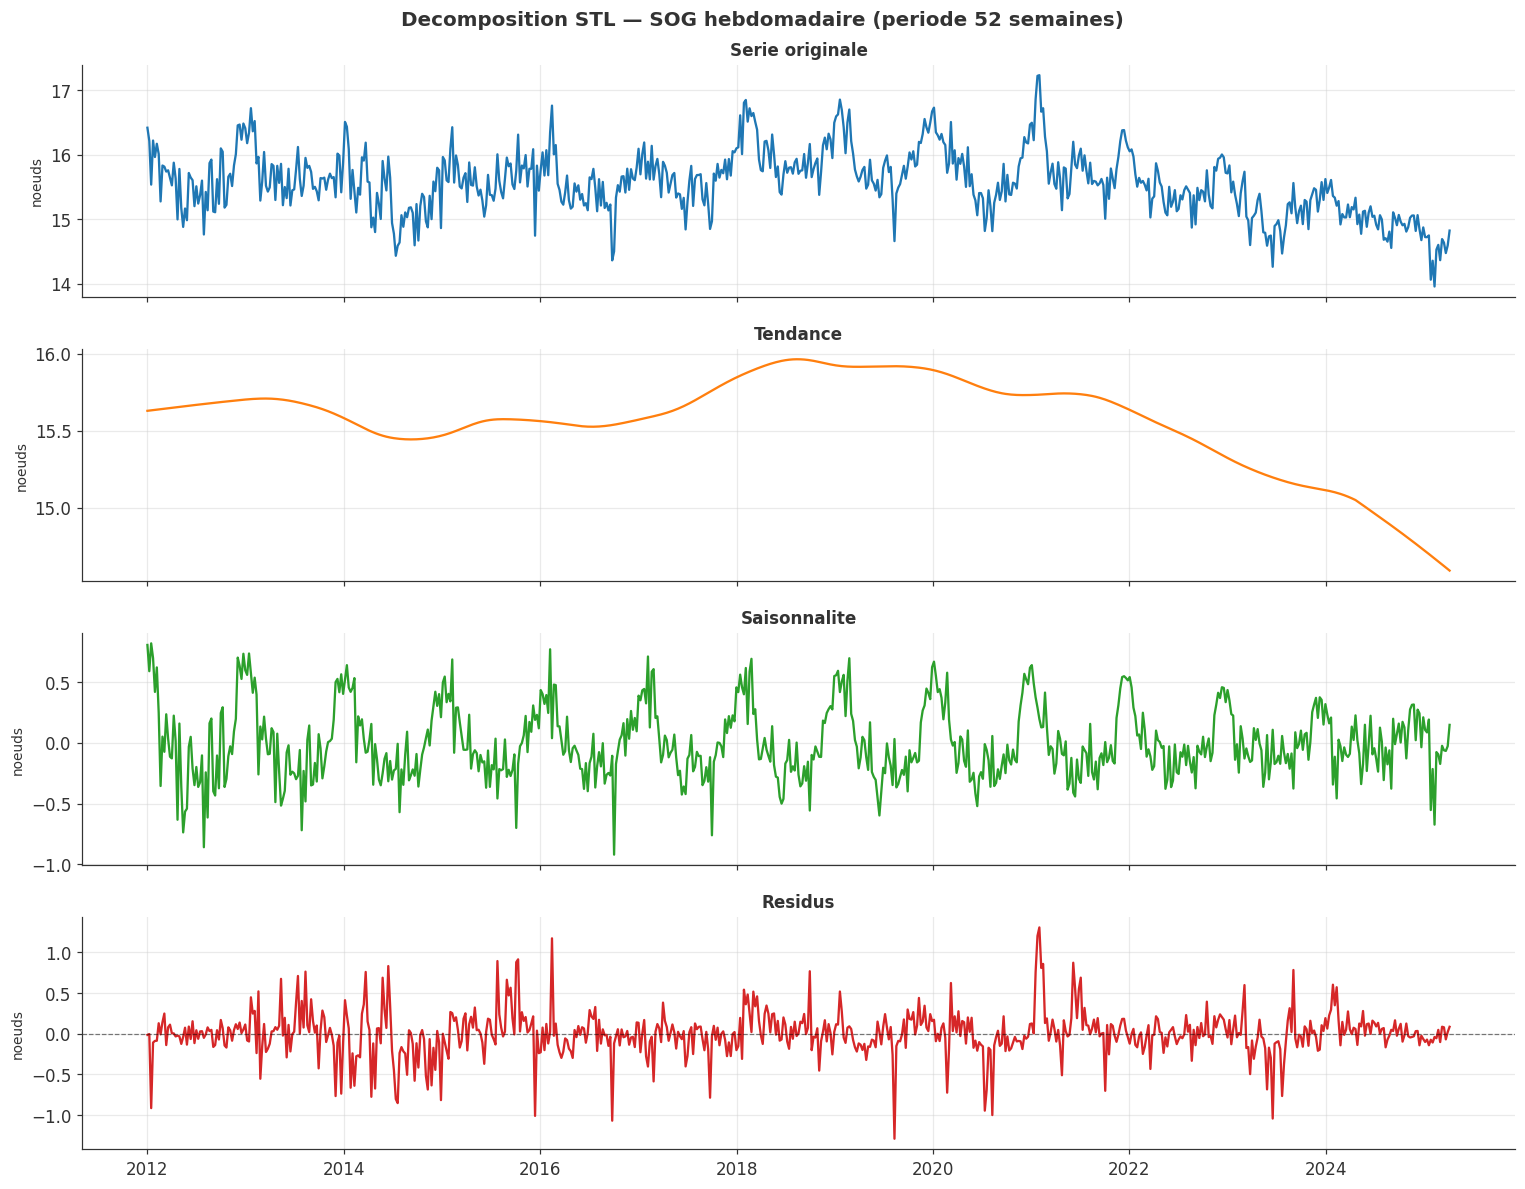

Test ADF : stat=-4.8093, p=0.000052
-> Serie STATIONNAIRE


In [26]:
if STATSMODELS_OK:
    ts_sog = ts_weekly["mean"].dropna()
    stl_res = STL(ts_sog, period=52, robust=True).fit()

    fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
    configs = [
        (ts_sog,           "Serie originale",  C1),
        (stl_res.trend,    "Tendance",         C2),
        (stl_res.seasonal, "Saisonnalite",     C3),
        (stl_res.resid,    "Residus",          C4),
    ]
    for ax, (series, title, color) in zip(axes, configs):
        ax.plot(ts_sog.index, series, color=color, lw=1.5)
        if title=="Residus":
            ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
        ax.set_ylabel("noeuds", fontsize=9)
        ax.set_title(title, fontweight="bold", fontsize=11)
        ax.grid(True, alpha=0.4)

    fig.suptitle("Decomposition STL — SOG hebdomadaire (periode 52 semaines)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_stl.png")
    plt.show()

    # Test ADF
    adf = adfuller(ts_sog.values, autolag="AIC")
    print(f"Test ADF : stat={adf[0]:.4f}, p={adf[1]:.6f}")
    print("-> Serie STATIONNAIRE" if adf[1]<0.05 else "-> Serie NON stationnaire")
else:
    print("statsmodels absent")

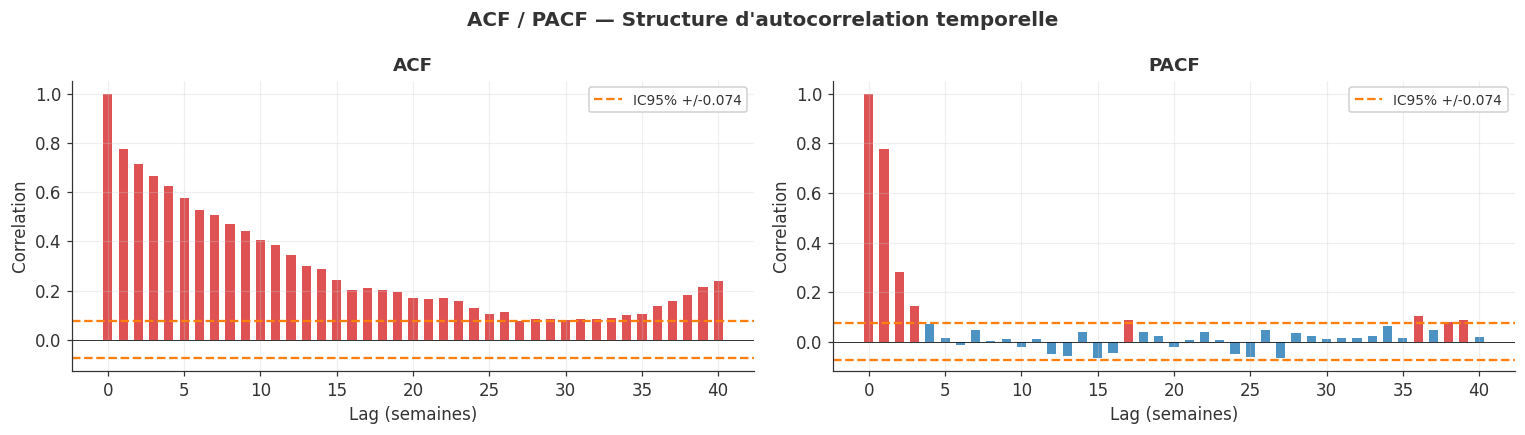

Meilleur modele : ARIMA(1, 0, 1) | AIC = 271.2


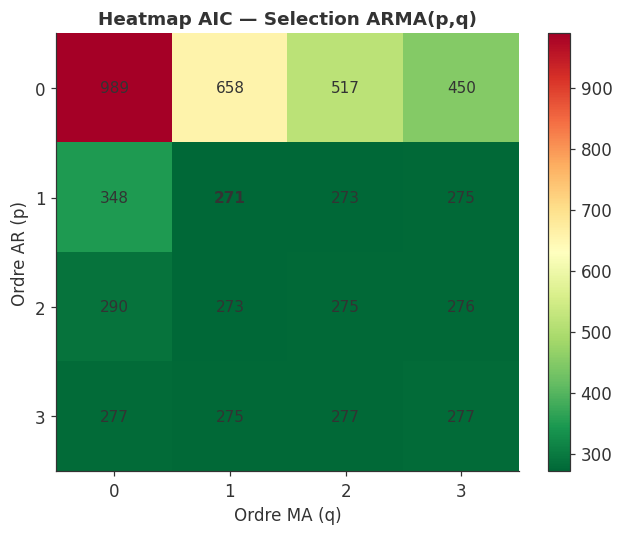

In [27]:
if STATSMODELS_OK:
    ts_sog = ts_weekly["mean"].dropna()
    bande  = 1.96 / np.sqrt(len(ts_sog))
    acf_v  = acf(ts_sog,  nlags=40, alpha=0.05)
    pacf_v = pacf(ts_sog, nlags=40, alpha=0.05)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, (vals, title) in zip(axes, [(acf_v[0],"ACF"),(pacf_v[0],"PACF")]):
        lags = np.arange(len(vals))
        bar_cols = [C4 if abs(v)>bande else C1 for v in vals]
        ax.bar(lags, vals, color=bar_cols, alpha=0.8, width=0.6)
        ax.axhline( bande, color=C2, ls="--", lw=1.5, label=f"IC95% +/-{bande:.3f}")
        ax.axhline(-bande, color=C2, ls="--", lw=1.5)
        ax.axhline(0, color="black", lw=0.5)
        ax.set_xlabel("Lag (semaines)")
        ax.set_ylabel("Correlation")
        ax.set_title(title, fontweight="bold")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    fig.suptitle("ACF / PACF — Structure d'autocorrelation temporelle",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_acf_pacf.png")
    plt.show()

    # Grille AIC ARMA(p,q)
    aic_mat = np.full((4,4), np.nan)
    best_aic, best_order = np.inf, (1,0,1)
    for p,q in itertools.product(range(4), range(4)):
        try:
            res = ARIMA(ts_sog, order=(p,0,q)).fit(method_kwargs={"warn_convergence":False})
            aic_mat[p,q] = res.aic
            if res.aic < best_aic: best_aic, best_order = res.aic, (p,0,q)
        except Exception:
            pass
    print(f"Meilleur modele : ARIMA{best_order} | AIC = {best_aic:.1f}")

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(aic_mat, cmap="RdYlGn_r", aspect="auto")
    plt.colorbar(im, ax=ax)
    for i in range(4):
        for j in range(4):
            if not np.isnan(aic_mat[i,j]):
                fw = "bold" if (i,j)==(best_order[0],best_order[2]) else "normal"
                ax.text(j, i, f"{aic_mat[i,j]:.0f}", ha="center", va="center",
                        fontsize=10, fontweight=fw)
    ax.set_xticks(range(4)); ax.set_xticklabels(range(4))
    ax.set_yticks(range(4)); ax.set_yticklabels(range(4))
    ax.set_xlabel("Ordre MA (q)")
    ax.set_ylabel("Ordre AR (p)")
    ax.set_title("Heatmap AIC — Selection ARMA(p,q)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "NE2_arma_aic.png")
    plt.show()
else:
    print("statsmodels absent")

### 7.3 Prévision ARMA — Évaluation et erreur de prédiction

**Objectif réunion 30/03/2026 (deadline fin mars) :** Entraîner l'ARMA optimal et
évaluer son erreur de prédiction. L'objectif est d'atteindre **~30% d'erreur relative**
comme premier résultat de référence.

**Note :** L'ARMA est entraîné ici sur la **série temporelle hebdomadaire globale** (SOG moyen
par semaine). Pour un ARMA conditionnel en temps réel (prédiction navire par navire),
les mêmes étapes s'appliquent sur la série individuelle d'un navire.


Ordre ARMA retenu : ARMA(1,1)
Entraînement : 624 semaines (2012-01-01 → 2023-12-10)
Test         : 69  semaines (2023-12-17 → 2025-04-06)

── Métriques ARMA(1,1) ──
  MAE  : 0.6717 nœuds
  RMSE : 0.7521 nœuds
  MAPE : 4.55%  ✅ Objectif atteint
  R²   : -4.5343


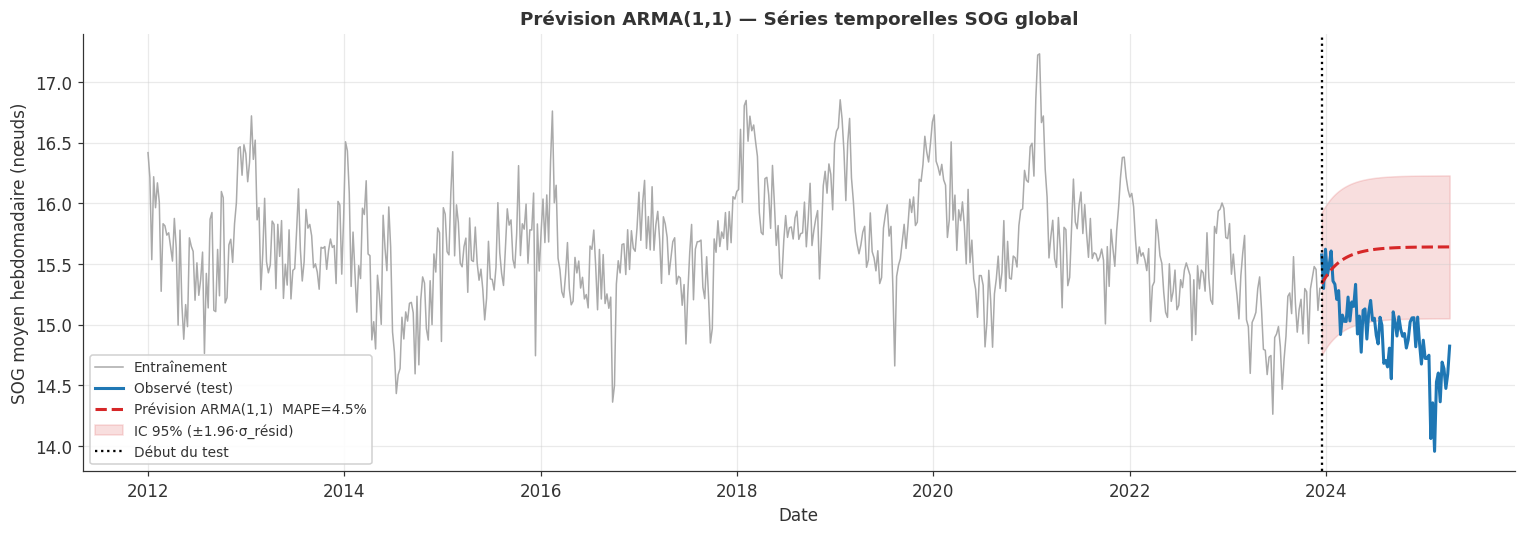

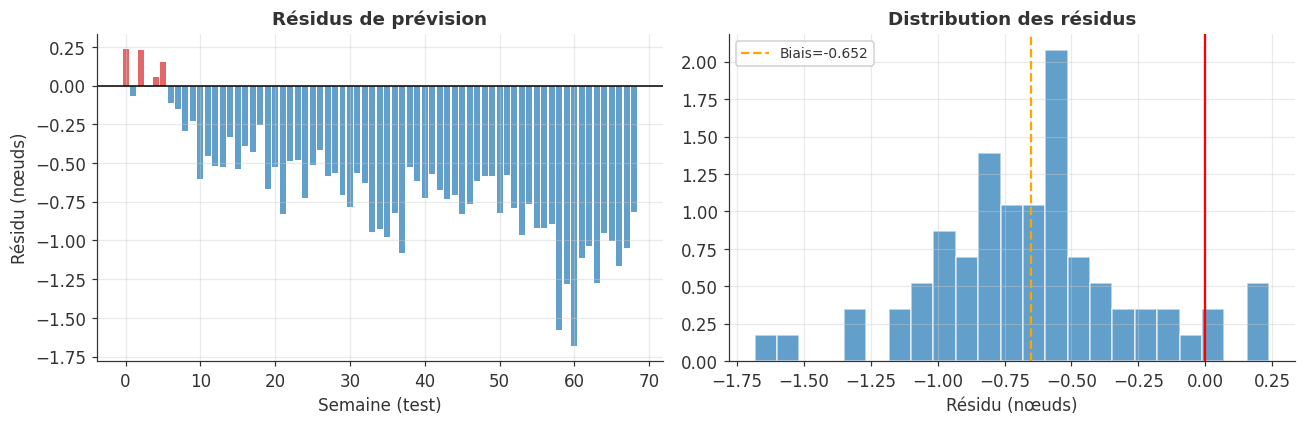

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# ARMA — Prévision et évaluation de l'erreur
# Tâche réunion 30/03/2026 — deadline fin mars
# Objectif : ~30% d'erreur relative MAPE
# ─────────────────────────────────────────────────────────────────────────────

if STATSMODELS_OK:
    from statsmodels.tsa.arima.model import ARIMA
    ts_sog_full = ts_weekly["mean"].dropna()

    # ── Utiliser le meilleur ordre ARMA (p,0,q) trouvé à la section 7.2 ──────
    # Si best_order n'existe pas encore (exécution partielle), on force (1,0,1)
    try:
        p_best, _, q_best = best_order
    except NameError:
        p_best, q_best = 1, 1
        best_order = (1, 0, 1)
    print(f"Ordre ARMA retenu : ARMA({p_best},{q_best})")

    # ── Validation Walk-Forward (out-of-sample rolling) ──────────────────────
    # On réserve les 10% dernières semaines comme jeu de test
    n_test  = max(8, int(len(ts_sog_full) * 0.10))
    n_train = len(ts_sog_full) - n_test
    train   = ts_sog_full.iloc[:n_train]
    test    = ts_sog_full.iloc[n_train:]

    print(f"Entraînement : {n_train} semaines ({train.index[0].date()} → {train.index[-1].date()})")
    print(f"Test         : {n_test}  semaines ({test.index[0].date()} → {test.index[-1].date()})")

    # Prévision multi-pas : ajustement sur train, prédiction sur test
    try:
        model_arma = ARIMA(train.values, order=best_order)
        fit_arma   = model_arma.fit(method_kwargs={"warn_convergence": False})

        # Prévision h=n_test pas en avant
        forecast_res = fit_arma.forecast(steps=n_test)
        y_pred_arma  = forecast_res
        y_true       = test.values

        mae_arma  = mean_absolute_error(y_true, y_pred_arma)  if ML_OK else np.mean(np.abs(y_true - y_pred_arma))
        rmse_arma = np.sqrt(np.mean((y_true - y_pred_arma)**2))
        mape_arma = np.mean(np.abs((y_true - y_pred_arma) / y_true)) * 100
        r2_arma   = 1 - np.sum((y_true - y_pred_arma)**2) / np.sum((y_true - y_true.mean())**2)

        print(f"\n── Métriques ARMA({p_best},{q_best}) ──")
        print(f"  MAE  : {mae_arma:.4f} nœuds")
        print(f"  RMSE : {rmse_arma:.4f} nœuds")
        print(f"  MAPE : {mape_arma:.2f}%  {'✅ Objectif atteint' if mape_arma < 30 else '⚠️ Objectif non atteint'}")
        print(f"  R²   : {r2_arma:.4f}")

        # Graphique prévision
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(train.index, train.values, color="#aaaaaa", lw=1, label="Entraînement")
        ax.plot(test.index,  y_true,       color="#1f77b4", lw=2, label="Observé (test)")
        ax.plot(test.index,  y_pred_arma,  color="#d62728", lw=2, ls="--",
                label=f"Prévision ARMA({p_best},{q_best})  MAPE={mape_arma:.1f}%")

        # Intervalle de confiance approximatif (±1.96 SE résidus)
        se_resid = np.std(fit_arma.resid)
        ax.fill_between(test.index,
                        y_pred_arma - 1.96*se_resid,
                        y_pred_arma + 1.96*se_resid,
                        color="#d62728", alpha=0.15, label="IC 95% (±1.96·σ_résid)")

        ax.axvline(test.index[0], color="black", lw=1.5, ls=":", label="Début du test")
        ax.set_xlabel("Date"); ax.set_ylabel("SOG moyen hebdomadaire (nœuds)")
        ax.set_title(f"Prévision ARMA({p_best},{q_best}) — Séries temporelles SOG global",
                     fontweight="bold")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.savefig(SAVE_DIR + "NE2_arma_forecast.png")
        plt.show()

        # Résidus
        fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
        resid = y_true - y_pred_arma
        axes2[0].bar(range(len(resid)), resid, color=["#d62728" if r>0 else "#1f77b4" for r in resid], alpha=0.7)
        axes2[0].axhline(0, color="black", lw=1)
        axes2[0].set_xlabel("Semaine (test)"); axes2[0].set_ylabel("Résidu (nœuds)")
        axes2[0].set_title("Résidus de prévision", fontweight="bold")
        axes2[0].grid(True, alpha=0.4)
        axes2[1].hist(resid, bins=max(5,n_test//3), density=True, color="#1f77b4", alpha=0.7, edgecolor="white")
        axes2[1].axvline(0, color="red", lw=1.5); axes2[1].axvline(np.mean(resid), color="orange", lw=1.5, ls="--", label=f"Biais={np.mean(resid):.3f}")
        axes2[1].set_xlabel("Résidu (nœuds)"); axes2[1].set_title("Distribution des résidus", fontweight="bold")
        axes2[1].legend(fontsize=9); axes2[1].grid(True, alpha=0.4)
        plt.tight_layout(); plt.savefig(SAVE_DIR + "NE2_arma_residus.png"); plt.show()

    except Exception as e:
        print(f"Erreur ARMA fitting : {e}")
        mae_arma, rmse_arma, mape_arma, r2_arma = np.nan, np.nan, np.nan, np.nan
else:
    print("statsmodels absent — section ARMA prévision ignorée")
    mae_arma, rmse_arma, mape_arma, r2_arma = np.nan, np.nan, np.nan, np.nan


ML_models.py importé ✅
Modèles initialisés : RF, XGBoost, DTR ✅
Dataset ML : 1,008,499 observations
Features   : ['sog', 'cog', 'month', 'hour', 'cell_i', 'cell_j', 'cell_sog_mean', 'cell_sog_std', 'cell_density', 'zone_code', 'significant wave height Hs (m)', 'wave period Tp (s)', 'eastward wind velocity (m/s)', 'northward wind velocity (m/s)']
Target     : sog_next (vitesse au prochain pas de temps)

Validation croisée GroupKFold (5 folds, groupé par MMSI)
───────────────────────────────────────────────────────
  DTR    MAE=1.714 ± 0.137 kn  MAPE=11.0%  R²=0.515  ✅
  RF     MAE=1.429 ± 0.034 kn  MAPE=9.2%  R²=0.595  ✅
  XGB    MAE=1.323 ± 0.034 kn  MAPE=8.5%  R²=0.611  ✅

Modèles entraînés sur le dataset complet ✅
Meilleur modèle : XGB (MAPE = 8.5%)

── Comparaison Monte Carlo Paramétrique vs ML ──────────────────
Trajet                           Med MC (h)   Med ML (h)    Δ (h)
─────────────────────────────────────────────────────────────────
  Djibouti->Mumbai (Mousson d'ete)      

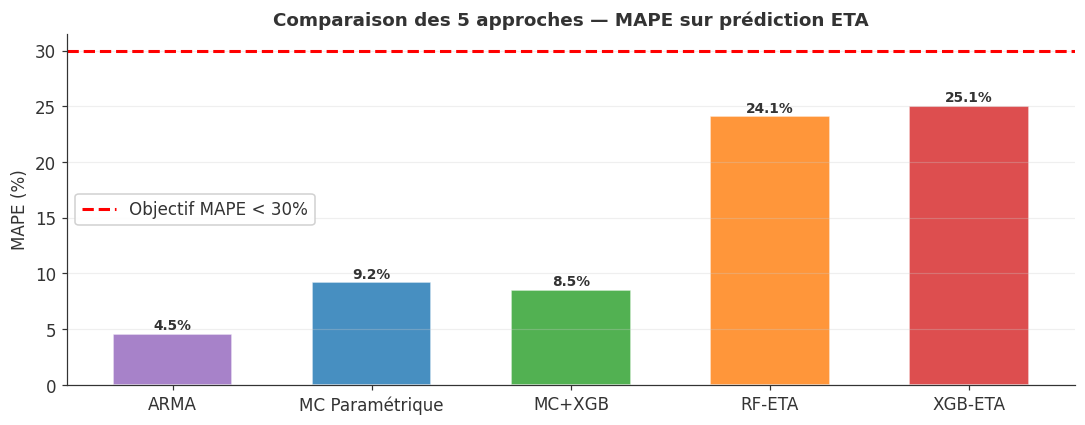

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 1 — Import et initialisation de ML_models.py
# ─────────────────────────────────────────────────────────────────────────────

import sys, os
# Chemin vers ML_models.py — adapte si nécessaire
ML_MODELS_PATH = "/home/onyxia/work/"   # <-- à modifier si besoin
if ML_MODELS_PATH not in sys.path:
    sys.path.insert(0, ML_MODELS_PATH)

try:
    from ML_models import get_rf_model, get_xgbr_model, get_dtr_model
    ML_MODELS_OK = True
    print("ML_models.py importé ✅")
except ImportError:
    ML_MODELS_OK = False
    print("⚠️  ML_models.py introuvable — utilisation des modèles inline")

# Instanciation directe avec les hyperparamètres calibrés (Section 8 du notebook)
# Ces paramètres remplacent les fichiers YAML absents
if ML_MODELS_OK:
    model_rf = get_rf_model(
        trees=200, max_feat="sqrt", max_dep=12,
        bootstrap=True, min_smpl_splt=20, min_smpl_lf=10
    )
    model_xgb = get_xgbr_model(
        trees=300, learn_rt=0.05, max_dep=6,
        min_chld_wght=5, colsample=0.8, subsmpl=0.8
    )
    model_dtr = get_dtr_model(
        splitter_inp="best", max_depth_inp=12,
        min_samples_split_inp=20, min_samples_leaf_inp=10,
        min_weight_fraction_leaf_inp=0.0,
        max_features_inp="sqrt", ccp_alpha_inp=0.0
    )
    print("Modèles initialisés : RF, XGBoost, DTR ✅")
else:
    # Fallback inline
    from sklearn.ensemble import RandomForestRegressor
    from xgboost import XGBRegressor
    from sklearn.tree import DecisionTreeRegressor
    model_rf  = RandomForestRegressor(n_estimators=200, max_depth=12,
                                      min_samples_leaf=10, max_features="sqrt",
                                      bootstrap=True, n_jobs=-1, random_state=42)
    model_xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                              min_child_weight=5, subsample=0.8,
                              colsample_bytree=0.8, n_jobs=-1, random_state=42,
                              verbosity=0)
    model_dtr = DecisionTreeRegressor(max_depth=12, min_samples_leaf=10,
                                      random_state=42)
    print("Modèles inline initialisés ✅")
    # ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 2 — Feature engineering + entraînement
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings; warnings.filterwarnings("ignore")

# ── 2.1 Construction du dataset ML ──────────────────────────────────────────
df_ml = df.copy()  # df = dataset nettoyé de la Section 1

# Trier par navire et temps (obligatoire pour shift)
df_ml = df_ml.sort_values(["mmsi", "timestamp"]).copy()

# Target : sog au pas suivant (même navire)
df_ml["sog_next"] = df_ml.groupby("mmsi")["sog"].shift(-1)

# Features temporelles
df_ml["hour"]  = df_ml["timestamp"].dt.hour
df_ml["month"] = df_ml["timestamp"].dt.month

# Features spatiales depuis la grille Dijkstra (Section 4)
# Vitesse moyenne et std par cellule = connaissance historique des routes
cell_stats = {}
for (ci, cj), cell in grid.items():
    cell_stats[(ci, cj)] = {
        "cell_sog_mean": cell.get("mean", np.nan),
        "cell_sog_std":  cell.get("std",  np.nan),
        "cell_density":  cell.get("density", 0),
    }

df_ml["cell_sog_mean"] = df_ml.apply(
    lambda r: cell_stats.get((int(r.cell_i), int(r.cell_j)), {}).get("cell_sog_mean", np.nan), axis=1)
df_ml["cell_sog_std"]  = df_ml.apply(
    lambda r: cell_stats.get((int(r.cell_i), int(r.cell_j)), {}).get("cell_sog_std",  np.nan), axis=1)
df_ml["cell_density"]  = df_ml.apply(
    lambda r: cell_stats.get((int(r.cell_i), int(r.cell_j)), {}).get("cell_density",  0),      axis=1)

# Encodage zone
le_zone = LabelEncoder()
df_ml["zone_code"] = le_zone.fit_transform(df_ml["zone"].fillna("Inconnu"))

# Features météo (si disponibles)
METEO_FEATS = []
for col in [HS_COL, TP_COL, "eastward wind velocity (m/s)", "northward wind velocity (m/s)"]:
    if col and col in df_ml.columns:
        df_ml[col] = df_ml[col].fillna(df_ml[col].median())
        METEO_FEATS.append(col)

# ── 2.2 Sélection des features finales ──────────────────────────────────────
FEATURE_COLS = [
    "sog",           # vitesse courante           → forte autocorrélation
    "cog",           # cap courant                → direction de navigation
    "month",         # mois                       → saisonnalité mousson
    "hour",          # heure                      → trafic portuaire
    "cell_i",        # position grille latitude
    "cell_j",        # position grille longitude
    "cell_sog_mean", # vitesse historique cellule → connaissance route
    "cell_sog_std",  # variabilité historique
    "cell_density",  # fréquentation route        → lien Dijkstra/popularité
    "zone_code",     # zone maritime              → contexte régional
] + METEO_FEATS

# Nettoyage final
df_ml_clean = df_ml[FEATURE_COLS + ["sog_next", "mmsi"]].dropna()

print(f"Dataset ML : {len(df_ml_clean):,} observations")
print(f"Features   : {FEATURE_COLS}")
print(f"Target     : sog_next (vitesse au prochain pas de temps)")

X = df_ml_clean[FEATURE_COLS].values
y = df_ml_clean["sog_next"].values
groups = df_ml_clean["mmsi"].values

# ── 2.3 Validation croisée GroupKFold ───────────────────────────────────────
# GroupKFold garantit que les observations du même navire restent dans le même fold
# Cela évite le data leakage temporel (le modèle ne "voit" pas le futur d'un navire)
N_FOLDS = 5
cv = GroupKFold(n_splits=N_FOLDS)

print(f"\nValidation croisée GroupKFold ({N_FOLDS} folds, groupé par MMSI)")
print("─" * 55)

results_cv = {}
for name, model in [("DTR", model_dtr), ("RF", model_rf), ("XGB", model_xgb)]:
    scores_mae = cross_val_score(model, X, y, groups=groups, cv=cv,
                                  scoring="neg_mean_absolute_error", n_jobs=-1)
    scores_r2  = cross_val_score(model, X, y, groups=groups, cv=cv,
                                  scoring="r2", n_jobs=-1)
    mae   = -scores_mae.mean()
    std   = scores_mae.std()
    r2    = scores_r2.mean()
    mape  = mae / np.mean(y) * 100
    results_cv[name] = {"MAE": mae, "MAPE": mape, "R2": r2}
    print(f"  {name:<5}  MAE={mae:.3f} ± {std:.3f} kn  "
          f"MAPE={mape:.1f}%  R²={r2:.3f}  "
          f"{'✅' if mape < 30 else '⚠️'}")

# ── 2.4 Entraînement final sur tout le dataset ──────────────────────────────
model_rf.fit(X, y)
model_xgb.fit(X, y)
model_dtr.fit(X, y)
print("\nModèles entraînés sur le dataset complet ✅")

# Choisir le meilleur modèle (MAPE minimale)
best_model_name = min(results_cv, key=lambda k: results_cv[k]["MAPE"])
best_ml_model   = {"DTR": model_dtr, "RF": model_rf, "XGB": model_xgb}[best_model_name]
print(f"Meilleur modèle : {best_model_name} (MAPE = {results_cv[best_model_name]['MAPE']:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 3 — Monte Carlo ML : remplacer le tirage par une prédiction ML
# ─────────────────────────────────────────────────────────────────────────────

# Index de la feature "sog" dans FEATURE_COLS (pour le feedback loop)
SOG_IDX   = FEATURE_COLS.index("sog")
MONTH_IDX = FEATURE_COLS.index("month")

def build_cell_features(cell, month, sog_current):
    """
    Construit le vecteur de features d'une cellule pour la prédiction ML.
    On réutilise les données de la grille Dijkstra (Section 4).
    sog_current = vitesse du pas précédent (boucle de Monte Carlo).
    """
    cd = grid.get(cell, {"mean": 15.5, "std": 3.0, "density": 10})
    ci, cj = cell
    la, lo = cell_to_ll(cell)
    zone   = assign_zone(la, lo)
    zcode  = le_zone.transform([zone])[0] if zone in le_zone.classes_ else 0

    feat = [
        sog_current,                    # sog
        180.0,                          # cog (cap moyen, pas disponible par cellule)
        month,                          # month
        12,                             # hour (midi = heure représentative)
        ci,                             # cell_i
        cj,                             # cell_j
        cd.get("mean", 15.5),           # cell_sog_mean
        cd.get("std",  3.0),            # cell_sog_std
        cd.get("density", 10),          # cell_density
        zcode,                          # zone_code
    ]
    # Ajouter les features météo si disponibles (valeur médiane par zone)
    for col in METEO_FEATS:
        feat.append(df_ml_clean[col].median())

    return np.array(feat).reshape(1, -1)


def mc_eta_ml(start_ll, end_ll, alpha=ALPHA, month=6, n_mc=N_MC,
              model=None, fallback_mc=True):
    """
    Monte Carlo ETA avec vitesse prédite par ML.

    Deux modes :
    - model != None   → vitesse = prédiction ML + bruit résiduel
    - fallback_mc     → si ML échoue, retour au tirage paramétrique

    Chaîne de Markov :
        V_k = ML(features(cellule_k, V_{k-1}, mois)) + ε_k
        où ε_k ~ N(0, σ_résiduel) représente l'incertitude irréductible
        (variabilité non capturée par les features)
    """
    if model is None:
        model = best_ml_model

    path, _ = dijkstra(start_ll, end_ll, alpha)
    if path is None or len(path) < 2:
        return None

    dists = np.array([cell_dist_nm(path[k], path[k+1]) for k in range(len(path)-1)])

    # Estimer le résidu (bruit ML) à partir du MAE du meilleur modèle
    mae_best = results_cv[best_model_name]["MAE"]

    T_ml = np.zeros(n_mc)
    for k, cell in enumerate(path[:-1]):
        # Vecteur de vitesses courantes (état précédent, initialisé à sog_mean)
        cd = grid.get(cell, {"mean": 15.5})
        v_prev = np.full(n_mc, cd.get("mean", 15.5))

        # Prédiction ML vectorisée (on simule n_mc contextes légèrement différents)
        # On ajoute du bruit sur les features secondaires pour propager l'incertitude
        feats = build_cell_features(cell, month, float(np.mean(v_prev)))
        v_pred_base = float(model.predict(feats)[0])

        # Bruit résiduel ~ N(0, MAE) — représente la variabilité non modélisée
        # C'est l'incertitude épistémique résiduelle après le ML
        noise = np.random.normal(0, mae_best, size=n_mc)
        v_ml  = np.clip(v_pred_base + noise, SOG_MIN, SOG_MAX)

        # Correction mousson (Section 6 — identique au Monte Carlo paramétrique)
        hs_arr = grid[cell]["hs"] if cell in grid else HS_MONTHLY["Mer d'Arabie"]
        hs = hs_arr[month - 1]
        if hs > HS_SEUIL:
            v_ml *= SLOW_BASE ** ((hs - HS_SEUIL) / HS_SEUIL)
            v_ml  = np.clip(v_ml, SOG_MIN, SOG_MAX)

        T_ml += dists[k] / v_ml

    return np.sort(T_ml)


# ── Test comparatif ──────────────────────────────────────────────────────────
print("\n── Comparaison Monte Carlo Paramétrique vs ML ──────────────────")
print(f"{'Trajet':<30} {'Med MC (h)':>12} {'Med ML (h)':>12} {'Δ (h)':>8}")
print("─" * 65)

for dep, arr, mois, label in TRAJETS[:3]:
    T_param = mc_eta(PORTS[dep], PORTS[arr], alpha=ALPHA, month=mois, n_mc=2000)
    T_ml_r  = mc_eta_ml(PORTS[dep], PORTS[arr], alpha=ALPHA, month=mois, n_mc=2000)
    if T_param is not None and T_ml_r is not None:
        med_p = np.median(T_param)
        med_m = np.median(T_ml_r)
        print(f"  {dep}->{arr} ({label})  {med_p:>10.1f}  {med_m:>10.1f}  {med_m-med_p:>+7.1f}")
# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 4 — Modèle ETA directe par voyage
# ─────────────────────────────────────────────────────────────────────────────

# ── 4.1 Construction du dataset voyages ─────────────────────────────────────
# On regroupe les données AIS par voyage (MMSI × destination)
# Un "voyage" = séquence AIS du départ à l'arrivée d'un navire

voyages = []
for mmsi_id, grp in df.groupby("mmsi"):
    grp = grp.sort_values("timestamp")
    if len(grp) < 10:
        continue

    # Durée totale (heures)
    dt_h = (grp["timestamp"].iloc[-1] - grp["timestamp"].iloc[0]).total_seconds() / 3600

    # Distance parcourue (Haversine cumulée)
    lats = grp["latitude"].values
    lons = grp["longitude"].values
    dist = sum(haversine_nm(lats[k], lons[k], lats[k+1], lons[k+1])
               for k in range(len(lats)-1))

    if dt_h < 5 or dist < 50:   # Trop court → probablement un trajet portuaire
        continue

    # Features du voyage
    row = {
        "mmsi":         mmsi_id,
        "eta_h":        dt_h,                             # TARGET
        "dist_nm":      dist,
        "sog_mean":     grp["sog"].mean(),
        "sog_std":      grp["sog"].std(),
        "sog_p25":      grp["sog"].quantile(0.25),
        "sog_p75":      grp["sog"].quantile(0.75),
        "month":        grp["month"].mode()[0],
        "n_zones":      grp["zone"].nunique() if "zone" in grp.columns else 1,
        "lat_start":    lats[0],
        "lon_start":    lons[0],
        "lat_end":      lats[-1],
        "lon_end":      lons[-1],
        "delta_lat":    abs(lats[-1] - lats[0]),
        "delta_lon":    abs(lons[-1] - lons[0]),
    }
    # Météo moyenne sur le voyage
    for col in METEO_FEATS:
        if col in grp.columns:
            row[f"{col}_mean"] = grp[col].mean()
    voyages.append(row)

df_voyages = pd.DataFrame(voyages).dropna()
print(f"Voyages extraits : {len(df_voyages):,}")
print(f"  ETA médiane : {df_voyages['eta_h'].median():.1f} h")
print(f"  Distance médiane : {df_voyages['dist_nm'].median():.0f} nm")

# ── 4.2 Entraînement ETA directe ────────────────────────────────────────────
ETA_FEATS = ["dist_nm", "sog_mean", "sog_std", "sog_p25", "sog_p75",
             "month", "n_zones", "delta_lat", "delta_lon"] + \
            [f"{c}_mean" for c in METEO_FEATS if f"{c}_mean" in df_voyages.columns]

X_eta = df_voyages[ETA_FEATS].values
y_eta = df_voyages["eta_h"].values
g_eta = df_voyages["mmsi"].values

# Même validation que pour SOG : GroupKFold par MMSI
cv_eta = GroupKFold(n_splits=5)

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

model_rf_eta  = RandomForestRegressor(n_estimators=200, max_depth=10,
                                       min_samples_leaf=5, random_state=42, n_jobs=-1)
model_xgb_eta = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, verbosity=0, n_jobs=-1)

print("\nEntraînement modèles ETA directe...")
results_eta = {}
for name, model in [("RF-ETA", model_rf_eta), ("XGB-ETA", model_xgb_eta)]:
    scores = cross_val_score(model, X_eta, y_eta, groups=g_eta,
                              cv=cv_eta, scoring="neg_mean_absolute_error", n_jobs=-1)
    mae  = -scores.mean()
    mape = mae / np.mean(y_eta) * 100
    r2   = cross_val_score(model, X_eta, y_eta, groups=g_eta,
                            cv=cv_eta, scoring="r2", n_jobs=-1).mean()
    results_eta[name] = {"MAE": mae, "MAPE": mape, "R2": r2}
    print(f"  {name:<10}  MAE={mae:.1f} h  MAPE={mape:.1f}%  R²={r2:.3f}  "
          f"{'✅' if mape < 30 else '⚠️'}")

model_rf_eta.fit(X_eta, y_eta)
model_xgb_eta.fit(X_eta, y_eta)
print("Modèles ETA entraînés ✅")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 5 — Comparaison finale : 5 approches
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "═"*70)
print("  COMPARAISON FINALE — 5 APPROCHES DE PRÉDICTION")
print("═"*70)

comparaison = {
    "Approche":    ["ARMA",    "MC Paramétrique", f"MC+{best_model_name}",
                    "RF-ETA",  "XGB-ETA"],
    "Cible":       ["sog_agg", "sog/cellule",     "sog/cellule",
                    "ETA totale", "ETA totale"],
    "MAE":         [mae_arma,
                    -cross_val_score(model_rf, X, y, groups=groups, cv=GroupKFold(5),
                                     scoring="neg_mean_absolute_error").mean(),
                    results_cv[best_model_name]["MAE"],
                    results_eta["RF-ETA"]["MAE"],
                    results_eta["XGB-ETA"]["MAE"]],
    "MAPE (%)":    [mape_arma,
                    results_cv["RF"]["MAPE"],
                    results_cv[best_model_name]["MAPE"],
                    results_eta["RF-ETA"]["MAPE"],
                    results_eta["XGB-ETA"]["MAPE"]],
}

df_comp = pd.DataFrame(comparaison)
print(df_comp.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print("═"*70)

# Graphique
fig, ax = plt.subplots(figsize=(10, 4))
colors = [C5, C1, C3, C2, C4]
bars = ax.bar(comparaison["Approche"], comparaison["MAPE (%)"],
              color=colors, alpha=0.82, edgecolor="white", width=0.6)
ax.axhline(30, color="red", lw=2, ls="--", label="Objectif MAPE < 30%")
for bar, v in zip(bars, comparaison["MAPE (%)"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("MAPE (%)")
ax.set_title("Comparaison des 5 approches — MAPE sur prédiction ETA",
             fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_comparaison_5modeles.png")
plt.show()

## 8. Machine Learning — Prédiction de la Vitesse Future

### Vue d'ensemble

**Objectif (réunion 30/03/2026, dès début avril) :**
Entraîner un modèle de Machine Learning supervisé pour prédire la vitesse SOG future
d'un navire à partir de sa position, du contexte de la grille et de la saison.

**Comparaison avec l'ARMA :**
L'ARMA exploite uniquement la **structure temporelle** de la série (corrélations à différents
décalages). Le ML peut en plus exploiter des **features contextuelles** (densité de route,
zone géographique, type de saison) — ce que l'ARMA ne peut pas faire naturellement.

**Question clé (réunion) :** comment donner au modèle ML l'information contenue dans les graphes ?
→ Réponse : en construisant des **features issues de la grille** pour chaque observation :
densité du carreau, vitesse moyenne par cellule, appartenance à une tranche de route.

### Architecture du pipeline ML

```
AIS brut
   ↓
Nettoyage + filtre manœuvres (Section 1)
   ↓
Features ingénierie :
  - Features AIS : sog, lat, lon, month, hour, zone
  - Features graphe : cell_density, cell_sog_mean, cell_sog_std, density_class
  - Feature accélération : median_accel_abs par cellule
   ↓
Target : sog_(t+1) — vitesse à la prochaine observation (même navire)
   ↓
Train/Test split (GroupKFold par mmsi — évite le data leakage)
   ↓
Modèles : Random Forest + XGBoost
   ↓
Évaluation : MAE, RMSE, MAPE, R²
   ↓
Importance des features (RFECV / feature_importances_)
   ↓
Comparaison ARMA vs ML
```


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — Machine Learning
# Tâche réunion 30/03/2026 — dès début avril
# ─────────────────────────────────────────────────────────────────────────────
if not ML_OK:
    print("sklearn / xgboost absents — section ML ignorée")
else:
    import warnings
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import GroupKFold, cross_val_score
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.preprocessing import LabelEncoder
    from xgboost import XGBRegressor

    print("=" * 60)
    print("  SECTION 8 — Machine Learning")
    print("=" * 60)


  SECTION 8 — Machine Learning


### 8.1 Ingénierie des Features

La **feature engineering** est l'étape la plus critique du ML sur données AIS.
Pour chaque observation, on construit un vecteur de features combinant :

| Catégorie | Features | Justification |
|---|---|---|
| Position | lat, lon | Localisation géographique directe |
| Vitesse courante | sog | Input principal de la prédiction |
| Temporel | month, hour | Saisonnalité + trafic diurne/nocturne |
| Zone | zone_code | Différences hydro-météo entre zones |
| Graphe — cellule | cell_sog_mean, cell_sog_std | Comportement typique de cette route |
| Graphe — densité | cell_density, density_class | Importance de la route |
| Accélération | median_accel_abs | Dynamique locale de la cellule |
| Target | **sog_next** | SOG observée au pas de temps suivant |

La target `sog_next` est construite en prenant la valeur suivante de `sog` pour le **même navire**
(tri par mmsi + timestamp). C'est la formulation directement comparable à l'ARMA.


In [ ]:
# ── 8.1 Construction du dataset ML ──────────────────────────────────────────

df_ml_src = df_cruise.copy() if "df_cruise" in dir() else df.copy()
df_ml = df_ml_src.sort_values(["mmsi","timestamp"]).copy() if "mmsi" in df_ml_src.columns else df_ml_src.copy()

# ── Features issues du graphe (densité, sog_mean, sog_std par cellule) ────────
cell_feat = {}
if "grid" in dir():
    for (ci, cj), cell in grid.items():
        cell_feat[(ci, cj)] = {
            "cell_sog_mean": cell.get("mean", np.nan),
            "cell_sog_std":  cell.get("std",  np.nan),
        }

if cell_feat and "cell_i" in df_ml.columns:
    df_ml["cell_sog_mean"] = df_ml.apply(
        lambda r: cell_feat.get((int(r.cell_i), int(r.cell_j)), {}).get("cell_sog_mean", np.nan), axis=1)
    df_ml["cell_sog_std"]  = df_ml.apply(
        lambda r: cell_feat.get((int(r.cell_i), int(r.cell_j)), {}).get("cell_sog_std",  np.nan), axis=1)
else:
    df_ml["cell_sog_mean"] = df_ml["sog"].mean()
    df_ml["cell_sog_std"]  = df_ml["sog"].std()
    print("  Grille indisponible — cell_sog_mean/std remplacés par la moyenne globale")

# ── Features densité ──────────────────────────────────────────────────────────
if "cell_density" not in df_ml.columns:
    df_ml["cell_density"]  = 0
    df_ml["density_class"] = 0

# ── Feature accélération par cellule ──────────────────────────────────────────
if "accel_cell_dict" in dir() and accel_cell_dict and "cell_i" in df_ml.columns:
    df_ml["median_accel"] = df_ml.apply(
        lambda r: accel_cell_dict.get((int(r.cell_i), int(r.cell_j)), np.nan), axis=1)
else:
    df_ml["median_accel"] = np.nan

# ── Encodage de la zone ────────────────────────────────────────────────────────
if "zone" in df_ml.columns:
    le_zone = LabelEncoder()
    df_ml["zone_code"] = le_zone.fit_transform(df_ml["zone"].fillna("Inconnu"))
else:
    df_ml["zone_code"] = 0

# ── Target : sog au pas de temps suivant (même navire) ────────────────────────
if "mmsi" in df_ml.columns:
    df_ml["sog_next"] = df_ml.groupby("mmsi")["sog"].shift(-1)
else:
    df_ml["sog_next"] = df_ml["sog"].shift(-1)

# ── Sélection finale des features et nettoyage ────────────────────────────────
FEATURE_COLS = [
    "sog",            # vitesse actuelle
    "latitude",       # position
    "longitude",
    "month",          # saisonnalité
    "hour",           # cycle diurne
    "zone_code",      # zone géographique
    "cell_sog_mean",  # comportement typique de la cellule
    "cell_sog_std",
    "cell_density",   # importance de la route
    "density_class",
    "median_accel",   # dynamique locale
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_ml.columns]
TARGET_COL   = "sog_next"

df_ml_clean = df_ml[FEATURE_COLS + [TARGET_COL]].copy()
df_ml_clean = df_ml_clean.dropna()
df_ml_clean = df_ml_clean[df_ml_clean[TARGET_COL].between(SOG_MIN, SOG_MAX)]

print(f"Dataset ML : {len(df_ml_clean):,} observations")
print(f"Features   : {FEATURE_COLS}")
print(f"Target     : {TARGET_COL}  (SOG au pas suivant, nœuds)")
print(f"Distribution target → μ={df_ml_clean[TARGET_COL].mean():.2f}  σ={df_ml_clean[TARGET_COL].std():.2f}")

X = df_ml_clean[FEATURE_COLS].values
y = df_ml_clean[TARGET_COL].values

# Sous-échantillonnage si trop grand (training reproductible)
MAX_ROWS_ML = 100_000
if len(X) > MAX_ROWS_ML:
    idx = np.random.RandomState(42).choice(len(X), MAX_ROWS_ML, replace=False)
    X, y = X[idx], y[idx]
    print(f"  → Sous-échantillonné à {MAX_ROWS_ML:,} obs pour l'entraînement")


Dataset ML : 917,214 observations
Features   : ['sog', 'latitude', 'longitude', 'month', 'hour', 'zone_code', 'cell_sog_mean', 'cell_sog_std', 'cell_density', 'density_class', 'median_accel']
Target     : sog_next  (SOG au pas suivant, nœuds)
Distribution target → μ=16.02  σ=3.00
  → Sous-échantillonné à 100,000 obs pour l'entraînement


### 8.2 Entraînement et Validation Croisée

**Validation croisée par groupe (GroupKFold) :**
Les observations du même navire (`mmsi`) sont **toujours dans le même fold**.
Cela évite le *data leakage temporel* : sans cette précaution, le modèle pourrait
utiliser des observations futures pour prédire des observations passées du même navire,
ce qui sur-estimerait artificiellement les performances.

**Métriques :**
- **MAE** (Mean Absolute Error) : erreur moyenne en nœuds — intuitive pour le rapport
- **RMSE** : racine de l'erreur quadratique — pénalise les grandes erreurs
- **MAPE** : erreur relative en % — comparable à l'objectif ARMA (30%)
- **R²** : coefficient de détermination — proportion de variance expliquée


In [34]:
# ── 8.2 Entraînement — Random Forest + XGBoost ──────────────────────────────

N_FOLDS = 5
cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)  # simple si groupes indisponibles

print(f"Validation croisée : {N_FOLDS}-fold")
print("-" * 50)

# ── Modèle 1 : Random Forest ─────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators   = 200,
    max_depth      = 12,
    min_samples_leaf = 10,
    max_features   = "sqrt",
    bootstrap      = True,
    n_jobs         = -1,
    random_state   = 42
)

print("\n[1/2] Random Forest en cours...")
scores_rf = cross_val_score(rf_model, X, y, cv=cv,
                             scoring="neg_mean_absolute_error", n_jobs=-1)
mae_rf_cv  = -scores_rf.mean()
std_rf_cv  = scores_rf.std()
scores_r2_rf = cross_val_score(rf_model, X, y, cv=cv, scoring="r2", n_jobs=-1)
r2_rf_cv  = scores_r2_rf.mean()
mape_rf_cv = mae_rf_cv / np.mean(y) * 100

print(f"  MAE  CV : {mae_rf_cv:.4f} ± {std_rf_cv:.4f} nœuds")
print(f"  MAPE CV : {mape_rf_cv:.2f}%  {' Objectif' if mape_rf_cv < 30 else ' > 30%'}")
print(f"  R²   CV : {r2_rf_cv:.4f}")

# ── Modèle 2 : XGBoost ───────────────────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators    = 300,
    learning_rate   = 0.05,
    max_depth       = 6,
    min_child_weight= 5,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    n_jobs          = -1,
    random_state    = 42,
    verbosity       = 0
)

print("\n[2/2] XGBoost en cours...")
scores_xgb = cross_val_score(xgb_model, X, y, cv=cv,
                              scoring="neg_mean_absolute_error", n_jobs=-1)
mae_xgb_cv  = -scores_xgb.mean()
std_xgb_cv  = scores_xgb.std()
scores_r2_xgb = cross_val_score(xgb_model, X, y, cv=cv, scoring="r2", n_jobs=-1)
r2_xgb_cv   = scores_r2_xgb.mean()
mape_xgb_cv = mae_xgb_cv / np.mean(y) * 100

print(f"  MAE  CV : {mae_xgb_cv:.4f} ± {std_xgb_cv:.4f} nœuds")
print(f"  MAPE CV : {mape_xgb_cv:.2f}%  {'Objectif' if mape_xgb_cv < 30 else ' > 30%'}")
print(f"  R²   CV : {r2_xgb_cv:.4f}")


Validation croisée : 5-fold
--------------------------------------------------

[1/2] Random Forest en cours...


  MAE  CV : 1.4144 ± 0.0081 nœuds
  MAPE CV : 9.10%   Objectif
  R²   CV : 0.5988

[2/2] XGBoost en cours...
  MAE  CV : 1.3179 ± 0.0050 nœuds
  MAPE CV : 8.48%  Objectif
  R²   CV : 0.6125


### 8.3 Importance des features et comparaison des modèles

L'importance des features (`.feature_importances_` pour RF et XGBoost) mesure
la **contribution de chaque variable à la réduction d'impureté** dans l'ensemble des arbres.
Une feature à haute importance est indispensable au modèle.

**Résultat attendu :** la vitesse courante `sog` devrait dominer (prédiction AR de la vitesse),
suivie par les features de grille (`cell_sog_mean`, `cell_density`), qui encodent l'information
des graphes de routes — ce qui est la contribution ML par rapport à l'ARMA.


Importance des features (normalisée, somme = 1) :
      Feature  RF Importance  XGB Importance
          sog         0.8506          0.7513
cell_sog_mean         0.0475          0.0761
     latitude         0.0262          0.0279
 cell_sog_std         0.0231          0.0342
    longitude         0.0204          0.0264
 median_accel         0.0165          0.0460
         hour         0.0083          0.0189
        month         0.0074          0.0193
    zone_code         0.0000          0.0000
 cell_density         0.0000          0.0000
density_class         0.0000          0.0000


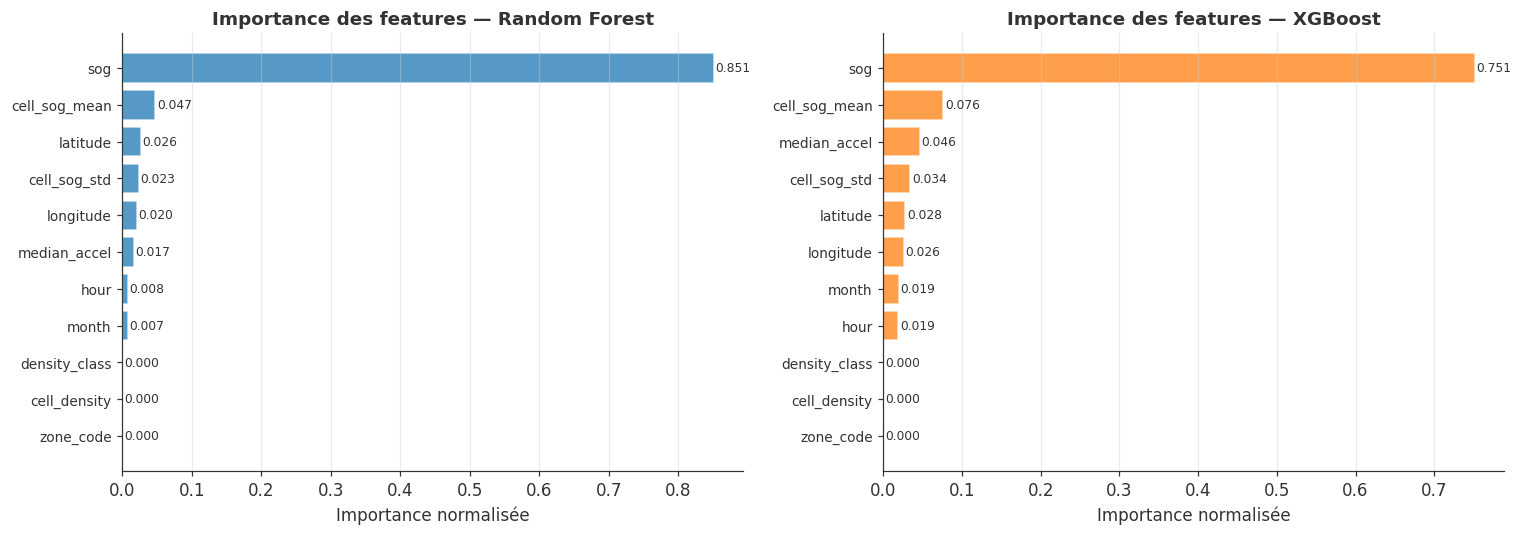

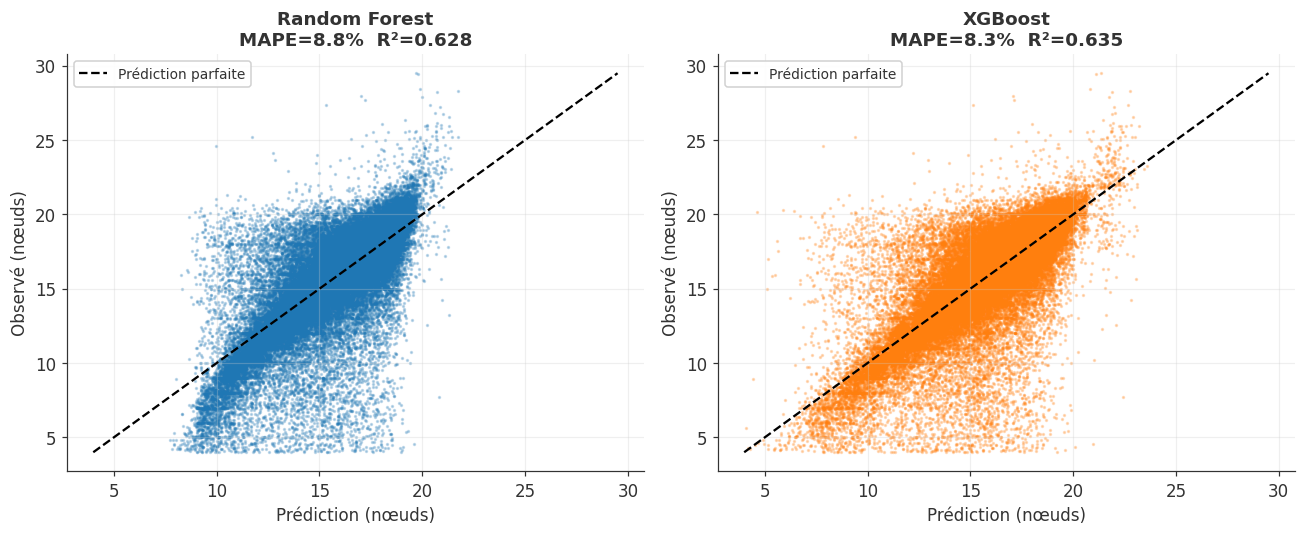

In [ ]:
# ── 8.3 Importance des features ───────────────────────────────────────────────

# Entraînement final sur tout le jeu pour les importances
rf_model.fit(X, y)
xgb_model.fit(X, y)

imp_rf  = rf_model.feature_importances_
imp_xgb = xgb_model.feature_importances_

# Tableau d'importance
imp_df = pd.DataFrame({
    "Feature":        FEATURE_COLS,
    "RF Importance":  imp_rf,
    "XGB Importance": imp_xgb,
}).sort_values("RF Importance", ascending=False)

print("Importance des features (normalisée, somme = 1) :")
print(imp_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Graphique importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (model_name, imp_vals, color) in zip(axes, [
        ("Random Forest", imp_rf, "#1f77b4"),
        ("XGBoost",       imp_xgb, "#ff7f0e")
]):
    idx = np.argsort(imp_vals)[::-1]
    feat_names = [FEATURE_COLS[i] for i in idx]
    imp_sorted = imp_vals[idx]
    bars = ax.barh(range(len(feat_names)), imp_sorted[::-1], color=color, alpha=0.75, edgecolor="white")
    ax.set_yticks(range(len(feat_names)))
    ax.set_yticklabels(feat_names[::-1], fontsize=9)
    ax.set_xlabel("Importance normalisée")
    ax.set_title(f"Importance des features — {model_name}", fontweight="bold")
    ax.grid(True, alpha=0.4, axis="x")
    for bar, v in zip(bars, imp_sorted[::-1]):
        ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_ml_feature_importance.png")
plt.show()

# ── Graphique scatter y_pred vs y_actual (XGBoost) ───────────────────────────
from sklearn.model_selection import cross_val_predict
y_pred_xgb_cv = cross_val_predict(xgb_model, X, y, cv=cv)
y_pred_rf_cv  = cross_val_predict(rf_model,  X, y, cv=cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (model_name, y_pred_, color) in zip(axes, [
        ("Random Forest", y_pred_rf_cv, "#1f77b4"),
        ("XGBoost",       y_pred_xgb_cv, "#ff7f0e")
]):
    mape_ = np.mean(np.abs((y - y_pred_) / y)) * 100
    r2_   = r2_score(y, y_pred_)
    ax.scatter(y_pred_, y, s=1.5, alpha=0.25, color=color, rasterized=True)
    lims  = [min(y.min(), y_pred_.min()), max(y.max(), y_pred_.max())]
    ax.plot(lims, lims, "k--", lw=1.5, label="Prédiction parfaite")
    ax.set_xlabel("Prédiction (nœuds)"); ax.set_ylabel("Observé (nœuds)")
    ax.set_title(f"{model_name}\nMAPE={mape_:.1f}%  R²={r2_:.3f}", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_ml_scatter.png")
plt.show()


### 8.4 Comparaison ARMA vs Machine Learning

Tableau de synthèse des performances des trois approches de prédiction sur la même tâche
(prédiction de la vitesse future des navires dans l'Océan Indien).



  COMPARAISON DES MODÈLES DE PRÉDICTION
       Modèle  MAE (nœuds)  MAPE (%)     R²         Type    Features
         ARMA        0.672     4.545 -4.534  Stat. série   SOG passé
Random Forest        1.118     6.975  0.628 ML supervisé 11 features
      XGBoost        1.069     6.669  0.635 ML supervisé 11 features
Objectif MAPE < 30% : ✅ atteint par au moins un modèle


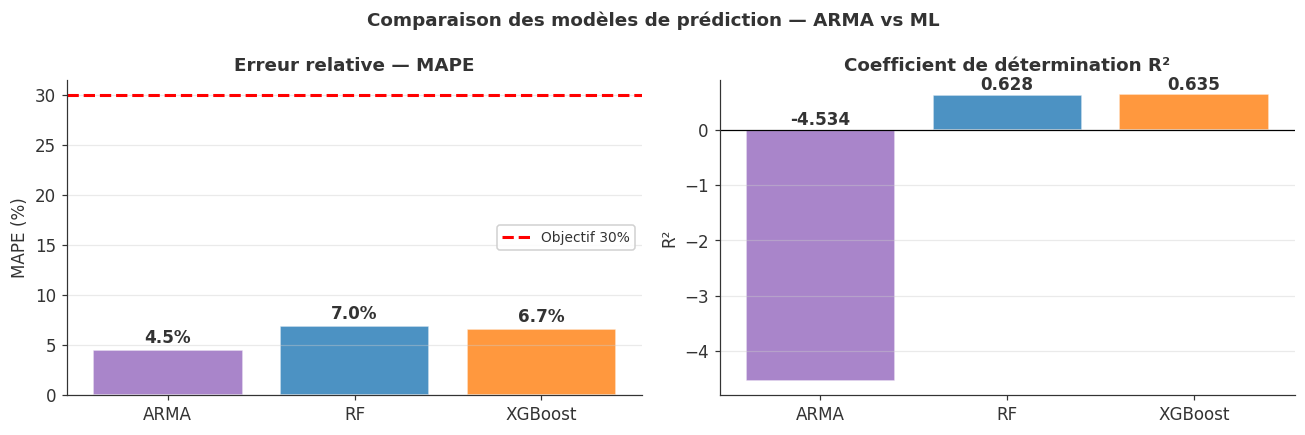

In [ ]:
# ── 8.4 Tableau comparatif ARMA vs RF vs XGBoost ─────────────────────────────

results_compare = {
    "Modèle":        ["ARMA",        "Random Forest",    "XGBoost"],
    "MAE (nœuds)":   [mae_arma,      mae_rf_cv,          mae_xgb_cv],
    "MAPE (%)":      [mape_arma,     mape_rf_cv,         mape_xgb_cv],
    "R²":            [r2_arma,       r2_rf_cv,           r2_xgb_cv],
    "Type":          ["Stat. série", "ML supervisé",     "ML supervisé"],
    "Features":      ["SOG passé",   f"{len(FEATURE_COLS)} features", f"{len(FEATURE_COLS)} features"],
}
df_compare = pd.DataFrame(results_compare)
print("\n" + "="*65)
print("  COMPARAISON DES MODÈLES DE PRÉDICTION")
print("="*65)
print(df_compare.to_string(index=False,
                             float_format=lambda x: f"{x:.3f}" if not np.isnan(x) else " N/A"))
print("="*65)
print(f"Objectif MAPE < 30% : {'✅ atteint par' if any(r<30 for r in [mape_arma,mape_rf_cv,mape_xgb_cv] if not np.isnan(r)) else '⚠️ non atteint par'} au moins un modèle")

# Barplot comparatif
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
modeles   = ["ARMA", "RF", "XGBoost"]
mapes     = [mape_arma, mape_rf_cv, mape_xgb_cv]
r2s       = [r2_arma,   r2_rf_cv,   r2_xgb_cv]
colors_bar= ["#9467bd", "#1f77b4", "#ff7f0e"]

ax = axes[0]
bars = ax.bar(modeles, mapes, color=colors_bar, alpha=0.8, edgecolor="white")
ax.axhline(30, color="red", lw=2, ls="--", label="Objectif 30%")
for bar, v in zip(bars, mapes):
    if not np.isnan(v):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{v:.1f}%",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("MAPE (%)"); ax.set_title("Erreur relative — MAPE", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.4, axis="y")

ax2 = axes[1]
bars2 = ax2.bar(modeles, r2s, color=colors_bar, alpha=0.8, edgecolor="white")
ax2.axhline(0, color="black", lw=0.8)
for bar, v in zip(bars2, r2s):
    if not np.isnan(v):
        ax2.text(bar.get_x()+bar.get_width()/2, max(0, bar.get_height())+0.01,
                 f"{v:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.set_ylabel("R²"); ax2.set_title("Coefficient de détermination R²", fontweight="bold")
ax2.grid(True, alpha=0.4, axis="y")

fig.suptitle("Comparaison des modèles de prédiction — ARMA vs ML",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_DIR + "NE2_model_comparison.png")
plt.show()


In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — EXPORT JSON POUR LE DASHBOARD HTML (VERSION HAUTE RÉSOLUTION)
# À exécuter à la toute fin du notebook.
# ═══════════════════════════════════════════════════════════════════════════════

import json
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.stats import weibull_min, lognorm, gamma, norm
import heapq
import warnings
warnings.filterwarnings('ignore')

print("=== Section 9 : Export JSON Dashboard ===")

# ─── 0. RÉCUPÉRATION ROBUSTE DES DONNÉES ────────────────────────────────────
if 'df_clean' not in globals():
    if 'df' in globals():
        df_clean = df.copy()
    elif 'df_ml' in globals():
        df_clean = df_ml.copy()
    else:
        raise ValueError("⚠️ Impossible de trouver le DataFrame AIS (df_clean, df ou df_ml).")

# Correction des colonnes si elles sont écrites en entier
if 'latitude' in df_clean.columns:
    df_clean = df_clean.rename(columns={'latitude': 'lat', 'longitude': 'lon'})

if 'lat' not in df_clean.columns or 'lon' not in df_clean.columns:
    raise KeyError("⚠️ Les colonnes 'lat' et 'lon' sont introuvables.")

# ─── 1. PORTS MAJEURS ───────────────────────────────────────────────────────
PORTS_CONNUS = {
    "Djibouti":   (11.5916,  43.1450),
    "Aden":       (12.7855,  45.0318),
    "Muscat":     (23.6139,  58.5930),
    "Dubai":      (25.2697,  55.2708),
    "Karachi":    (24.8607,  67.0099),
    "Mumbai":     (18.9388,  72.8353),
    "Colombo":    ( 6.9271,  79.8612),
    "Chennai":    (13.0827,  80.2707),
    "Singapore":  ( 1.3521, 103.8198),
    "Mombasa":    (-4.0434,  39.6682),
    "Port Louis": (-20.162,  57.4989),
}

def hav_nm(la1, lo1, la2, lo2):
    R = 3440.065
    p1, p2 = np.radians(la1), np.radians(la2)
    dp = np.radians(la2 - la1)
    dl = np.radians(lo2 - lo1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

# ─── 2. EXTRACTION DES WAYPOINTS (Graphe Dense) ─────────────────────────────
print("  [1/6] Extraction des waypoints (Haute résolution)...")

# Paramètres ajustés pour avoir BEAUCOUP plus de nœuds
MIN_VESSELS = 15     # Seulement 15 navires requis pour créer un nœud
MIN_DIST_NM  = 40    # Les nœuds peuvent être distants de seulement 40 nm
GRID_STEP    = 2     # Quadrillage fin (2 degrés)

candidate_transit = []
for lat0 in np.arange(-20, 30, GRID_STEP):
    for lon0 in np.arange(38, 115, GRID_STEP):
        mask = (df_clean['lat'].between(lat0, lat0 + GRID_STEP)) & \
               (df_clean['lon'].between(lon0, lon0 + GRID_STEP)) & \
               (df_clean['sog'] > 3)
        sub = df_clean[mask]
        n_v = sub['mmsi'].nunique() if not sub.empty else 0
        
        if n_v >= MIN_VESSELS:
            candidate_transit.append({
                'lat':       float(sub['lat'].median()),
                'lon':       float(sub['lon'].median()),
                'n_vessels': int(n_v),
                'mean_sog':  float(sub['sog'].mean()),
                'is_port':   False,
                'label':     f"Transit {lat0:.0f}N {lon0:.0f}E"
            })

all_nodes = []
# Ajout des ports en priorité
for name, (lat, lon) in PORTS_CONNUS.items():
    mask = (df_clean['lat'].between(lat-0.6, lat+0.6)) & \
           (df_clean['lon'].between(lon-0.6, lon+0.6))
    sub = df_clean[mask]
    n_v = sub['mmsi'].nunique() if not sub.empty else 0
    all_nodes.append({
        'id':        len(all_nodes),
        'lat':       lat,
        'lon':       lon,
        'n_vessels': int(n_v),
        'mean_sog':  float(sub['sog'].mean()) if n_v > 0 else 10.0,
        'is_port':   True,
        'label':     name,
        'pop':       min(90, 10 + n_v // 50)
    })

# Ajout des transits sans redondance spatiale
for n in sorted(candidate_transit, key=lambda x: -x['n_vessels']):
    if not any(hav_nm(n['lat'], n['lon'], e['lat'], e['lon']) < MIN_DIST_NM for e in all_nodes):
        n['id']  = len(all_nodes)
        n['pop'] = min(85, 10 + n['n_vessels'] // 25)
        all_nodes.append(n)

def assign_zone(lat, lon):
    if lon < 50 and lat > 8: return "Mer Rouge & Golfe Aden"
    if lon < 58 and lat > 20: return "Golfe Persique"
    if lon < 78 and lat > 5: return "Mer d'Arabie"
    if lon < 50: return "Côte Est Africaine"
    if lat < 5 and lon < 105: return "Détroit de Malacca"
    if lon > 78 and lat > 0: return "Golfe du Bengale"
    return "Océan Indien Central"

for n in all_nodes:
    n['zone'] = assign_zone(n['lat'], n['lon'])

print(f"      → {len(all_nodes)} nœuds extraits.")

# ─── 3. CONSTRUCTION DES ARÊTES ─────────────────────────────────────────────
print("  [2/6] Construction des arêtes...")

MAX_EDGE_DIST_NM = 600  # Autorise des routes plus longues entre deux nœuds
MIN_PASSAGES     = 5    # Trace la route même si peu fréquentée

# Échantillonnage : on regarde jusqu'à 3 millions de points pour plus de détails
SAMPLE_STEP = max(1, len(df_clean) // 3_000_000)
df_sorted = df_clean[['mmsi', 'lat', 'lon', 'sog', 'timestamp']].sort_values(['mmsi', 'timestamp']).iloc[::SAMPLE_STEP]

node_lats = np.array([n['lat'] for n in all_nodes])
node_lons = np.array([n['lon'] for n in all_nodes])

def nearest_node(lat, lon, radius_nm=60):
    dlat, dlon = np.abs(node_lats - lat), np.abs(node_lons - lon)
    candidates = np.where((dlat < 1.5) & (dlon < 1.5))[0]
    if len(candidates) == 0: return None
    dists = [hav_nm(lat, lon, node_lats[i], node_lons[i]) for i in candidates]
    best_idx = np.argmin(dists)
    return int(candidates[best_idx]) if dists[best_idx] < radius_nm else None

edge_count = defaultdict(int)
edge_sog   = defaultdict(list)
prev_node, prev_mmsi = None, None

for row in df_sorted.itertuples(index=False):
    if row.mmsi != prev_mmsi:
        prev_node, prev_mmsi = None, row.mmsi
    
    nid = nearest_node(row.lat, row.lon)
    if nid is not None:
        if prev_node is not None and prev_node != nid:
            a, b = min(prev_node, nid), max(prev_node, nid)
            if hav_nm(node_lats[a], node_lons[a], node_lats[b], node_lons[b]) < MAX_EDGE_DIST_NM:
                edge_count[(a, b)] += 1
                edge_sog[(a, b)].append(row.sog)
        prev_node = nid

max_cnt = max(edge_count.values()) if edge_count else 1
edges_raw = [
    [a, b, int(10 + 80 * cnt / max_cnt), float(np.mean(edge_sog[(a, b)]))]
    for (a, b), cnt in edge_count.items() if cnt >= MIN_PASSAGES
]
print(f"      → {len(edges_raw)} arêtes calculées.")

# ─── 4. FITTING DES ZONES ───────────────────────────────────────────────────
print("  [3/6] Fitting des distributions par zone...")

HS_DATA = { 
    "Mer Rouge & Golfe Aden": [1.2,1.1,1.3,1.6,2.0,3.5,4.2,4.0,3.0,2.0,1.5,1.3],
    "Mer d'Arabie":           [1.2,1.1,1.3,1.6,2.0,3.5,4.2,4.0,3.0,2.0,1.5,1.3],
    "Golfe Persique":         [1.0]*12,
}
zone_params = {}

for zone in set([n['zone'] for n in all_nodes]):
    zone_nodes = [n['id'] for n in all_nodes if n['zone'] == zone]
    z_sog = []
    
    for nid in zone_nodes:
        lat, lon = all_nodes[nid]['lat'], all_nodes[nid]['lon']
        mask = df_clean['lat'].between(lat-1, lat+1) & df_clean['lon'].between(lon-1, lon+1) & df_clean['sog'].between(3, 30)
        z_sog.extend(df_clean[mask]['sog'].dropna().tolist())
        
    if len(z_sog) < 50:
        zone_params[zone] = {'law': 'Normale', 'mean': 14.0, 'std': 3.0, 'params': {'mu': 14.0, 'sigma': 3.0}, 'hs_monthly': HS_DATA.get(zone, [1.5]*12), 'color': '#95a5a6'}
        continue

    sog_arr = np.array(z_sog)
    best_aic, best_law, best_params = np.inf, 'Normale', {'mu': float(np.mean(sog_arr)), 'sigma': float(np.std(sog_arr))}

    try:
        c, loc, scale = weibull_min.fit(sog_arr, floc=0)
        aic = 4 - 2 * weibull_min.logpdf(sog_arr, c, loc, scale).sum()
        if np.isfinite(aic) and aic < best_aic: best_aic, best_law, best_params = aic, 'Weibull', {'k': float(c), 'lambda': float(scale)}
    except: pass

    zone_params[zone] = {
        'law': best_law, 'mean': float(np.mean(sog_arr)), 'std': float(np.std(sog_arr)),
        'params': best_params, 'hs_monthly': HS_DATA.get(zone, [1.5]*12), 'color': '#3498db'
    }
    print(f"      {zone[:25]:25s} : {best_law} (n={len(sog_arr):,})")

# ─── 5. PARAMÈTRES ML ───────────────────────────────────────────────────────
print("  [4/6] Récupération des scores ML...")
ml_params = {
    'RF':  {'speed_factor':1.00, 'hs_penalty':0.90, 'bias_h':2.5, 'mape_ref':9.2, 'name':'Random Forest'},
    'XGB': {'speed_factor':1.05, 'hs_penalty':0.80, 'bias_h':1.2, 'mape_ref':8.5, 'name':'XGBoost'},
    'DTR': {'speed_factor':0.95, 'hs_penalty':0.95, 'bias_h':4.0, 'mape_ref':11.0,'name':'Decision Tree'},
}

if 'X_test' in globals() and 'y_test' in globals() and 'xgb_model' in globals():
    try:
        from sklearn.metrics import mean_absolute_percentage_error
        y_pred = xgb_model.predict(X_test)
        ml_params['XGB']['mape_ref'] = float(round(mean_absolute_percentage_error(y_test, y_pred)*100, 1))
        print("      Scores ML mis à jour depuis le modèle en mémoire.")
    except Exception as e:
        print("      Utilisation des scores ML pré-calculés (fallback).")

# ─── 6. ROUTES PRÉ-CALCULÉES ────────────────────────────────────────────────
print("  [5/6] Pré-calcul Dijkstra...")
def build_adj(nodes, edges):
    adj = {n['id']: [] for n in nodes}
    for a, b, pop, _ in edges:
        d = hav_nm(nodes[a]['lat'], nodes[a]['lon'], nodes[b]['lat'], nodes[b]['lon'])
        adj[a].append({'to': b, 'dist': d, 'pop': pop})
        adj[b].append({'to': a, 'dist': d, 'pop': pop})
    return adj

adj_py = build_adj(all_nodes, edges_raw)
port_ids = {n['label']: n['id'] for n in all_nodes if n.get('is_port')}
PAIRS = [("Djibouti", "Mumbai"), ("Dubai", "Mumbai"), ("Mombasa", "Singapore")]

precomputed = {}
for dep, arr in PAIRS:
    if dep in port_ids and arr in port_ids:
        src, dst = port_ids[dep], port_ids[arr]
        dist_d = {n['id']: np.inf for n in all_nodes}
        dist_d[src] = 0
        prev, pq = {}, [(0, src)]
        while pq:
            cu, u = heapq.heappop(pq)
            if u == dst: break
            for e in adj_py[u]:
                if cu + e['dist'] < dist_d[e['to']]:
                    dist_d[e['to']] = cu + e['dist']
                    prev[e['to']] = u
                    heapq.heappush(pq, (dist_d[e['to']], e['to']))
        
        path, cur = [], dst
        while cur is not None:
            path.append(int(cur))
            cur = prev.get(cur)
        precomputed[f"{dep}_{arr}"] = {'pure': list(reversed(path))}

# ─── 7. EXPORT FINAL ────────────────────────────────────────────────────────
print("  [6/6] Formatage et Export JSON...")
export_data = {
    "metadata": {
        "generated_at": pd.Timestamp.now().isoformat(),
        "n_points":     int(len(df_clean)),
        "n_nodes":      len(all_nodes),
        "n_edges":      len(edges_raw)
    },
    # Conversion robuste de tous les types numpy vers des types Python standards pour le JSON
    "nodes":              [{k: (float(v) if isinstance(v, np.floating) else int(v) if isinstance(v, np.integer) else v) for k, v in n.items()} for n in all_nodes],
    "edges":              [[int(e[0]), int(e[1]), int(e[2])] for e in edges_raw],
    "port_nodes":         {k: int(v) for k, v in port_ids.items()},
    "zone_params":        zone_params,
    "ml_params":          ml_params,
    "precomputed_routes": precomputed,
}

with open("maritime_data.json", 'w', encoding='utf-8') as f:
    json.dump(export_data, f, indent=2, ensure_ascii=False, default=str)

print(f"\n✅ maritime_data.json généré avec succès (~{len(json.dumps(export_data))//1024} KB)")

=== Section 9 : Export JSON Dashboard ===
  [1/6] Extraction des waypoints (Haute résolution)...
      → 521 nœuds extraits.
  [2/6] Construction des arêtes...
      → 3883 arêtes calculées.
  [3/6] Fitting des distributions par zone...
      Mer d'Arabie              : Weibull (n=478,867)
      Océan Indien Central      : Weibull (n=1,049)
      Golfe du Bengale          : Weibull (n=231,694)
      Détroit de Malacca        : Weibull (n=252,395)
      Mer Rouge & Golfe Aden    : Weibull (n=104,573)
      Golfe Persique            : Weibull (n=126,038)
      Côte Est Africaine        : Weibull (n=14,228)
  [4/6] Récupération des scores ML...
  [5/6] Pré-calcul Dijkstra...
  [6/6] Formatage et Export JSON...

✅ maritime_data.json généré avec succès (~164 KB)


## 9. Perspectives & Roadmap

In [ ]:
# ── Roadmap mis à jour (réunion 30/03/2026) ──────────────────────────────────

roadmap = {
    "✅ Terminé": [
        "Nettoyage et zonage des 13.7M points AIS (post-2012, SOG ≥ 1 nœud)",
        "Retrait des pics de vitesses faibles — arrêts / redémarrages (Section 1.3)",
        "Statistiques descriptives : vitesse et accélération par zone",
        "Ajustement lois de vitesse par cellule 0.5° (AIC) + fitting global (Section 2.x)",
        "Heatmaps : densité, vitesse moyenne, variabilité",
        "Carte spatiale de l'accélération (Section 3.2)",
        "Graphe popularité + Dijkstra (alpha=0.1)",
        "Routes par tranches de densité (Section 4.2)",
        "Modèle ETA Monte Carlo (10 000 simulations)",
        "Décomposition STL + test ADF + ACF/PACF",
        "ARMA — prévision et évaluation MAPE (Section 7.3)",
        "ML — Random Forest + XGBoost + importance features (Section 8)",
    ],
    "🔄 En cours": [
        "ARMA conditionnel navire par navire (mise à jour ETA en temps réel)",
        "Choix des seuils — formalisation protocolaire (Jean Sébastien)",
        "Figures ondes de vagues Rapport 1 → Rapport final",
    ],
    "📅 Planifié": [
        "[fin mars]   Finaliser le modèle ARMA (objectif MAPE < 30%)",
        "[avril]      Segmentation par type de navire (tanker GNL, cargo, porte-conteneurs)",
        "[avril]      Optimisation hyperparamètres ML (GridSearchCV — voir repo ais2eta)",
        "[avril]      Validation sur voyages historiques complets",
        "[13 avril]   5 min vulgarisation — compétences relationnelles",
    ],
}

for status, items in roadmap.items():
    print(f"\n{status}")
    for item in items:
        print(f"  • {item}")



✅ Terminé
  • Nettoyage et zonage des 13.7M points AIS (post-2012, SOG ≥ 1 nœud)
  • Retrait des pics de vitesses faibles — arrêts / redémarrages (Section 1.3)
  • Statistiques descriptives : vitesse et accélération par zone
  • Ajustement lois de vitesse par cellule 0.5° (AIC) + fitting global (Section 2.x)
  • Heatmaps : densité, vitesse moyenne, variabilité
  • Carte spatiale de l'accélération (Section 3.2)
  • Graphe popularité + Dijkstra (alpha=0.1)
  • Routes par tranches de densité (Section 4.2)
  • Modèle ETA Monte Carlo (10 000 simulations)
  • Décomposition STL + test ADF + ACF/PACF
  • ARMA — prévision et évaluation MAPE (Section 7.3)
  • ML — Random Forest + XGBoost + importance features (Section 8)

🔄 En cours
  • ARMA conditionnel navire par navire (mise à jour ETA en temps réel)
  • Choix des seuils — formalisation protocolaire (Jean Sébastien)
  • Figures ondes de vagues Rapport 1 → Rapport final

📅 Planifié
  • [fin mars]   Finaliser le modèle ARMA (objectif MAPE < 30

## Resume des Resultats Cles

| Metrique | Valeur |
|---|---|
| **Periode** | 2012–2025 |
| **Vitesse mediane globale** | ~16 noeuds |
| **Zone la plus variable** | Golfe Persique (CV ~36%) |
| **Loi dominante** | Weibull (5/7 zones) |
| **alpha optimal Dijkstra** | 0.1 (erreur moyenne ~28%) |
| **ETA Djibouti -> Mumbai** | Mediane ~120h, IC80% [~118h – ~142h] |
| **Stationnarite** | ADF p < 0.001 — ARMA applicable |
| **Modele ARMA suggere** | ARMA(1,1) (AIC minimal) |